<a href="https://colab.research.google.com/github/ABHI20-STAT/Fractal_and_Research/blob/main/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Abstract**

The quadratic family

$$
f_c(z)=z^2+c,\qquad c\in\mathbb{C},
$$

plays a central role in complex dynamics through its connection with the Mandelbrot set, Julia sets, and the escape geometry of critical orbits. In the escaping regime, the critical orbit grows on a super-exponential scale, making direct analysis of $|{f_c^{\circ n}(0)}|$ analytically inconvenient and numerically unstable. To overcome this, we study the regularized escape-rate function

$$
G(c)=\lim_{n\to\infty}\frac{\log^{+}|{f_c^{\circ n}(0)}|}{2^n}.
$$

We prove the existence of this limit for escaping parameters, show that it vanishes on the Mandelbrot set, and establish the asymptotic law
$$
\log|{f_c^{\circ n}(0)|}=2^nG(c)+o(2^n),
\qquad
|{f_c^{\circ n}(0)|}=\exp\!\bigl(2^nG(c)+o(2^n)\bigr).
$$
This identifies \(G(c)\) as the precise coefficient governing the double-exponential growth of escaping critical orbits and shows that logarithmic normalization is the natural regularization for quadratic iteration. We further develop a quantitative convergence theory for the finite approximants

$$
G_n(c)=\frac{\log^+|z_n|}{2^n},
$$

derive an explicit $O(2^{-n})$ error bound, and obtain a rigorous stopping criterion for prescribed computational accuracy. These estimates yield error-controlled numerical algorithms for approximating $G(c)$ for escaping parameters once the critical orbit has crossed a prescribed escape radius. Finally, we illustrate the theory through worked real and complex examples, numerical tables, and visualizations, demonstrating how regularization transforms explosive orbit growth into a finite, geometrically meaningful, and computationally robust parameter-space function.

# **Quantitative Regularization of Escape Rates in Quadratic Complex Dynamics**

## 1. Overview

This notebook accompanies the study of regularized escape rates for the quadratic family

$$
f_c(z)=z^2+c,\qquad c\in\mathbb C.
$$

For each parameter $c$, we consider the critical orbit

$$
z_0=0,\qquad z_{n+1}=z_n^2+c.
$$

The behaviour of this orbit determines whether the parameter belongs to the Mandelbrot set. If the critical orbit remains bounded, then $c$ belongs to the Mandelbrot set. If the critical orbit escapes to infinity, then $c$ lies outside the Mandelbrot set.

The purpose of regularization is to replace the rapidly growing raw sequence $|z_n|$ by a stable normalized logarithmic quantity. This makes it possible to study escape in a finite, meaningful, and computationally robust way.

---

## 2. The Mandelbrot Set and the Critical Orbit

The Mandelbrot set is defined by

$$
\mathcal M
=
\left\{
c\in\mathbb C:
\sup_{n\geq 0}|f_c^{\circ n}(0)|<\infty
\right\}.
$$

Equivalently, using the critical orbit $z_0=0$ and $z_{n+1}=z_n^2+c$,

$$
c\in\mathcal M
\quad\Longleftrightarrow\quad
\sup_{n\geq 0}|z_n|<\infty.
$$

Thus there are two basic regimes:

1. **Bounded regime**:  
   The orbit remains bounded and $c\in\mathcal M$.

2. **Escaping regime**:  
   The orbit escapes to infinity and $c\notin\mathcal M$.

---

## 3. Why Regularization Is Needed

For escaping parameters $c\notin\mathcal M$, the critical orbit does not merely diverge. Once the orbit is sufficiently far from the origin, the quadratic term dominates the additive term $c$, so the iteration behaves approximately like

$$
|z_{n+1}|\approx |z_n|^2.
$$

Taking logarithms gives

$$
\log |z_{n+1}|
\approx
2\log |z_n|.
$$

Thus the natural scale for the logarithmic growth is $2^n$. This motivates the normalized logarithmic quantity

$$
G_n(c)
=
\frac{\log^+|z_n|}{2^n},
$$

where

$$
\log^+ r=\max\{\log r,0\}.
$$

The role of this normalization is to convert explosive orbit growth into a finite asymptotic observable.

---

## 4. Escape-Rate Function

The regularized escape-rate function is defined by

$$
G(c)
=
\lim_{n\to\infty}
\frac{\log^+|z_n|}{2^n},
$$

whenever the limit exists.

For escaping parameters, after sufficiently many iterates one has $|z_n|>1$, so

$$
\log^+|z_n|=\log|z_n|.
$$

Hence, in the escaping regime, the finite approximants may be written as

$$
G_n(c)
=
\frac{\log |z_n|}{2^n}.
$$

The main idea is that $G(c)$ measures the leading logarithmic coefficient of escape.

---

## 5. Bounded Parameters

If $c\in\mathcal M$, then the critical orbit is bounded. Therefore, there exists a constant $R>0$ such that

$$
|z_n|\leq R
\qquad
\text{for all } n\geq 0.
$$

Then

$$
0
\leq
G_n(c)
=
\frac{\log^+|z_n|}{2^n}
\leq
\frac{\log^+R}{2^n}.
$$

Since

$$
\frac{\log^+R}{2^n}\to 0,
$$

we obtain

$$
G(c)=0
\qquad
\text{for } c\in\mathcal M.
$$

Thus the escape-rate function vanishes on the Mandelbrot set.

---

## 6. Escaping Parameters

If $c\notin\mathcal M$, then the critical orbit escapes to infinity. Once the orbit enters a sufficiently large region, the term $z_n^2$ dominates the recurrence

$$
z_{n+1}=z_n^2+c.
$$

For large $|z_n|$, the growth is governed by repeated squaring:

$$
|z_{n+1}|\approx |z_n|^2.
$$

This implies that the raw magnitude $|z_n|$ grows on a double-exponential scale, while $\log |z_n|$ grows on the scale $2^n$.

The regularized approximants

$$
G_n(c)=\frac{\log |z_n|}{2^n}
$$

therefore converge to a finite value $G(c)$ for escaping parameters.

---

## 7. Asymptotic Interpretation

For escaping parameters $c\notin\mathcal M$, the escape-rate function satisfies the asymptotic law

$$
\log |z_n|
=
2^nG(c)+o(2^n).
$$

Equivalently,

$$
|z_n|
=
\exp\!\left(2^nG(c)+o(2^n)\right).
$$

This means that $G(c)$ is the leading coefficient governing the logarithmic growth of the escaping critical orbit.

Importantly, $G(c)$ is not a universal constant such as $\log 2$. Its value depends on the parameter $c$. Different escaping parameters can have different escape-rate values.

---

## 8. Why the Model $|z_n|\sim K2^n$ Is Not Correct

A merely exponential model such as

$$
|z_n|\sim K2^n
$$

is not compatible with quadratic iteration in the escaping regime.

Indeed, if

$$
|z_n|\sim K2^n,
$$

then one would expect

$$
|z_{n+1}|\sim K2^{n+1}.
$$

But the recurrence gives

$$
|z_{n+1}|\approx |z_n|^2.
$$

Substituting the exponential model gives

$$
|z_{n+1}|
\approx
K^2 2^{2n}.
$$

The two quantities

$$
K2^{n+1}
\qquad
\text{and}
\qquad
K^2 2^{2n}
$$

do not have the same asymptotic growth. Therefore, a simple exponential model does not describe the escaping dynamics correctly.

The correct asymptotic scale is captured by

$$
|z_n|
=
\exp\!\left(2^nG(c)+o(2^n)\right).
$$

---

## 9. Non-Universality of the Escape Rate

It is incorrect to claim that

$$
G(c)=\log 2
\qquad
\text{for all } c\notin\mathcal M.
$$

The escape-rate function depends on the parameter $c$.

For example, two different escaping parameters $c_1$ and $c_2$ may satisfy

$$
G(c_1)<G(c_2).
$$

This means that the critical orbit for $c_2$ escapes with a larger leading logarithmic coefficient than the critical orbit for $c_1$.

Thus $G(c)$ is a genuine parameter-space function, not a universal constant.

---

## 10. Exact Increment Identity

After the orbit has entered the escaping regime, the finite approximants satisfy an exact increment identity.

Starting from

$$
z_{n+1}=z_n^2+c
=
z_n^2\left(1+\frac{c}{z_n^2}\right),
$$

we obtain

$$
|z_{n+1}|
=
|z_n|^2
\left|1+\frac{c}{z_n^2}\right|.
$$

Taking logarithms gives

$$
\log |z_{n+1}|
=
2\log |z_n|
+
\log\left|1+\frac{c}{z_n^2}\right|.
$$

Dividing by $2^{n+1}$ gives

$$
G_{n+1}(c)-G_n(c)
=
\frac{1}{2^{n+1}}
\log\left|1+\frac{c}{z_n^2}\right|.
$$

This identity explains why the normalized sequence stabilizes: once $|z_n|$ is large, the term

$$
\frac{c}{z_n^2}
$$

becomes small.

---

## 11. Certified Error Bound

Suppose the orbit has crossed an escape radius $R$ satisfying

$$
R>\max\{2,\sqrt{2|c|}\}.
$$

Assume that for some index $n_0$,

$$
|z_{n_0}|\geq R.
$$

Then for every $n\geq n_0$, the error between the limiting escape rate and the finite approximant is bounded by

$$
|G(c)-G_n(c)|
\leq
\frac{1}{2^n}
\left[
-\log\left(1-\frac{|c|}{R^2}\right)
\right].
$$

This shows that the convergence is exponentially fast in the iteration index $n$.

---

## 12. Simplified Error Bound

Using the inequality

$$
-\log(1-x)\leq 2x
\qquad
\text{for } 0\leq x<\frac12,
$$

one obtains the simpler estimate

$$
|G(c)-G_n(c)|
\leq
\frac{2|c|}{2^nR^2}.
$$

This bound is weaker than the logarithmic bound, but it is easier to interpret.

---

## 13. Stopping Criterion

Given a tolerance $\varepsilon>0$, we want to choose $n$ so that

$$
|G(c)-G_n(c)|\leq \varepsilon.
$$

It is sufficient to require

$$
\frac{1}{2^n}
\left[
-\log\left(1-\frac{|c|}{R^2}\right)
\right]
\leq
\varepsilon.
$$

Equivalently,

$$
2^n
\geq
\frac{1}{\varepsilon}
\left[
-\log\left(1-\frac{|c|}{R^2}\right)
\right].
$$

Therefore, a certified stopping index is

$$
n_{\mathrm{stop}}
=
\max\left\{
n_0,\,
\left\lceil
\log_2\left(
\frac{1}{\varepsilon}
\left[
-\log\left(1-\frac{|c|}{R^2}\right)
\right]
\right)
\right\rceil
\right\}.
$$

This gives a mathematically justified stopping rule for computing $G(c)$ to a prescribed tolerance.

---

## 14. Stabilized Approximation for Visualization

For visualization over parameter space, it is often useful to stop the iteration once the orbit crosses a bailout radius $B$.

If

$$
\tau=\min\{n\leq N: |z_n(c)|>B\},
$$

then one records

$$
\widehat G_N(c)
=
\frac{\log |z_\tau(c)|}{2^\tau}.
$$

If the orbit does not cross the bailout radius within $N$ iterations, one records

$$
\widehat G_N(c)
=
\frac{\log^+|z_N(c)|}{2^N}.
$$

This stabilized finite approximation is useful for heat maps, contour plots, and numerical exploration of the escape-rate field.

However, $\widehat G_N(c)$ is primarily a visualization tool unless it is supplemented by the certified error bound above.

---

## 15. Computational Interpretation

The computation proceeds as follows:

1. Choose a parameter $c$.
2. Start with $z_0=0$.
3. Iterate

$$
z_{n+1}=z_n^2+c.
$$

4. At each step compute

$$
G_n(c)=\frac{\log^+|z_n|}{2^n}.
$$

5. If the orbit crosses a certified radius $R$, use the error bound

$$
|G(c)-G_n(c)|
\leq
\frac{1}{2^n}
\left[
-\log\left(1-\frac{|c|}{R^2}\right)
\right].
$$

6. Stop when the certified error is below the prescribed tolerance.

Thus the method is not merely heuristic. It provides an error-controlled way to approximate the escape-rate function.

---

## 16. Summary

The raw critical-orbit magnitude $|z_n|$ grows too rapidly to be a stable observable in the escaping regime. The logarithmically normalized quantity

$$
G_n(c)=\frac{\log^+|z_n|}{2^n}
$$

extracts the correct asymptotic scale and converges to the escape-rate function

$$
G(c)=\lim_{n\to\infty}G_n(c).
$$

For bounded parameters,

$$
G(c)=0.
$$

For escaping parameters,

$$
G(c)>0,
$$

and the asymptotic growth law is

$$
\log |z_n|
=
2^nG(c)+o(2^n).
$$

The value of $G(c)$ depends on the parameter $c$. It is not universally equal to $\log 2$.

The quantitative error estimate and stopping criterion make the regularized escape-rate function suitable for certified numerical computation and parameter-space visualization.



# 4. Formal Basis for the Regularization Process

Without regularization, the orbit magnitude $|z_n|$ may grow extremely rapidly when the parameter $c$ lies outside the Mandelbrot set. For the quadratic iteration

$$
z_{n+1}=z_n^2+c,
\qquad
z_0=0,
$$

an escaping critical orbit satisfies

$$
|z_n|\to\infty.
$$

Once the orbit is sufficiently far from the origin, the quadratic term dominates the additive term $c$, so the recurrence is approximately governed by

$$
|z_{n+1}|\approx |z_n|^2.
$$

Taking logarithms gives

$$
\log |z_{n+1}|
\approx
2\log |z_n|.
$$

Thus the logarithm converts repeated squaring into an approximately linear growth rule on the logarithmic scale. Since the degree of the quadratic map is $2$, the natural normalization after $n$ iterations is $2^n$.

Therefore, the regularized finite approximants are defined by

$$
G_n(c)=\frac{\log^+|z_n|}{2^n},
$$

where

$$
\log^+ r=\max\{\log r,0\}.
$$

For escaping orbits, after sufficiently many iterations one has $|z_n|>1$, so

$$
\log^+|z_n|=\log|z_n|.
$$

Hence, in the escaping regime, one writes

$$
G_n(c)=\frac{\log |z_n|}{2^n}.
$$

The limiting escape-rate function is

$$
G(c)=\lim_{n\to\infty}G_n(c),
$$

whenever the limit exists.

Regularization is useful here because:

1. **The logarithm reduces explosive growth** by converting repeated squaring into additive growth on the logarithmic scale.

2. **The denominator $2^n$ matches the degree growth** of the quadratic map.

3. **The normalized quantity remains finite** even though the raw orbit magnitude $|z_n|$ diverges.

4. **The limit gives a meaningful escape-rate measurement** for each escaping parameter.

Importantly, the limiting value $G(c)$ is not universally equal to $\log 2$. The value of $G(c)$ depends on the parameter $c$.

---

# 5. Theoretical and Practical Implications of Regularization

The regularization

$$
G_n(c)=\frac{\log^+|z_n|}{2^n}
$$

has several important theoretical and computational consequences.

## 5.1. Well-Defined Escape Rate

Without regularization, the quantity $|z_n|$ becomes too large to compare directly. In contrast, the normalized logarithmic quantity $G_n(c)$ often stabilizes rapidly for escaping parameters.

For $c\notin\mathcal M$, the sequence $G_n(c)$ converges to the escape-rate function

$$
G(c)=\lim_{n\to\infty}G_n(c).
$$

Thus $G(c)$ provides a finite measurement of the leading logarithmic escape speed of the critical orbit.

---

## 5.2. Vanishing on the Mandelbrot Set

If $c\in\mathcal M$, then the critical orbit remains bounded. Hence there exists $R>0$ such that

$$
|z_n|\leq R
\qquad
\text{for all } n\geq 0.
$$

Then

$$
0
\leq
G_n(c)
=
\frac{\log^+|z_n|}{2^n}
\leq
\frac{\log^+R}{2^n}.
$$

Since

$$
\frac{\log^+R}{2^n}\to 0,
$$

we obtain

$$
G(c)=0
\qquad
\text{for } c\in\mathcal M.
$$

Thus the escape-rate function vanishes on the Mandelbrot set.

---

## 5.3. Parameter-Dependent Escape

For escaping parameters, one has

$$
G(c)>0.
$$

However, $G(c)$ is not the same for all escaping parameters. Different choices of $c$ may produce different limiting escape-rate values.

If

$$
G(c_1)<G(c_2),
$$

then the critical orbit for $c_2$ escapes with a larger leading logarithmic coefficient than the critical orbit for $c_1$.

This means that $G(c)$ is a genuine parameter-space function, not a universal constant.

---

## 5.4. Asymptotic Growth Law

For escaping parameters $c\notin\mathcal M$, the regularized escape-rate function satisfies

$$
\log |z_n|
=
2^nG(c)+o(2^n).
$$

Equivalently,

$$
|z_n|
=
\exp\!\left(2^nG(c)+o(2^n)\right).
$$

This shows that the raw orbit magnitude grows on a double-exponential scale, while the normalized logarithmic quantity converges to the finite value $G(c)$.

---

## 5.5. Computational Robustness

Regularization is also computationally useful. The raw orbit values $z_n$ may become too large to store accurately, but the normalized logarithmic values

$$
G_n(c)=\frac{\log^+|z_n|}{2^n}
$$

remain stable.

This allows us to:

1. Approximate $G(c)$ numerically.
2. Plot convergence curves for $G_n(c)$.
3. Generate parameter-space heat maps.
4. Compute approximate equipotential curves.
5. Use certified error bounds after the orbit crosses a sufficiently large escape radius.

---

# 6. Worked Example: The Parameter $c=2$

We start with

$$
z_0=0,
\qquad
z_{n+1}=z_n^2+2.
$$

The first few iterates are

$$
z_1=2,
$$

$$
z_2=2^2+2=6,
$$

$$
z_3=6^2+2=38,
$$

$$
z_4=38^2+2=1446.
$$

Therefore,

$$
G_1(2)=\frac{\log 2}{2},
$$

$$
G_2(2)=\frac{\log 6}{4},
$$

$$
G_3(2)=\frac{\log 38}{8},
$$

$$
G_4(2)=\frac{\log 1446}{16}.
$$

Numerically,

$$
G_1(2)\approx 0.34657359,
$$

$$
G_2(2)\approx 0.44793987,
$$

$$
G_3(2)\approx 0.45483874,
$$

$$
G_4(2)\approx 0.45471929.
$$

Thus the approximants stabilize near

$$
G(2)\approx 0.4547.
$$

This confirms that the escape-rate value is not universally equal to $\log 2$.

Since

$$
|z_4|=1446>10,
$$

the orbit has crossed the escape radius $R=10$. Therefore, the certified error estimate can be applied.

For $c=2$, $R=10$, and $n=4$,

$$
|G(2)-G_4(2)|
\leq
\frac{1}{2^4}
\left[
-\log\left(1-\frac{2}{10^2}\right)
\right].
$$

Hence

$$
|G(2)-G_4(2)|
\leq
\frac{1}{16}
\left[-\log(0.98)\right].
$$

Numerically,

$$
|G(2)-G_4(2)|
\leq
0.00126271.
$$

Therefore,

$$
|G(2)-0.45471929|
\leq
0.00126271.
$$

---

# 7. Worked Example: The Parameter $c=1$

We start with

$$
z_0=0,
\qquad
z_{n+1}=z_n^2+1.
$$

The first few iterates are

$$
z_1=1,
$$

$$
z_2=1^2+1=2,
$$

$$
z_3=2^2+1=5,
$$

$$
z_4=5^2+1=26,
$$

$$
z_5=26^2+1=677.
$$

The corresponding finite approximants are

$$
G_1(1)=0,
$$

$$
G_2(1)=\frac{\log 2}{4},
$$

$$
G_3(1)=\frac{\log 5}{8},
$$

$$
G_4(1)=\frac{\log 26}{16},
$$

$$
G_5(1)=\frac{\log 677}{32}.
$$

Numerically,

$$
G_2(1)\approx 0.17328680,
$$

$$
G_3(1)\approx 0.20117974,
$$

$$
G_4(1)\approx 0.20362249,
$$

$$
G_5(1)\approx 0.20367693.
$$

Thus

$$
G(1)\approx 0.20368.
$$

This again shows that the limiting escape rate depends on $c$.

Since

$$
|z_4|=26>10,
$$

the orbit has crossed the escape radius. At $n=5$, the certified bound gives

$$
|G(1)-G_5(1)|
\leq
\frac{1}{2^5}
\left[
-\log\left(1-\frac{1}{10^2}\right)
\right].
$$

Thus

$$
|G(1)-G_5(1)|
\leq
\frac{1}{32}
\left[-\log(0.99)\right].
$$

Numerically,

$$
|G(1)-G_5(1)|
\leq
0.00031407.
$$

Therefore,

$$
|G(1)-0.20367693|
\leq
3.15\times 10^{-4}.
$$

---

# 8. Worked Example: The Parameter $c=1.5+1.5i$

Let

$$
c=1.5+1.5i.
$$

Starting from $z_0=0$, we get

$$
z_1=1.5+1.5i.
$$

Next,

$$
z_2=(1.5+1.5i)^2+(1.5+1.5i).
$$

Since

$$
(1.5+1.5i)^2=4.5i,
$$

we obtain

$$
z_2=1.5+6i.
$$

Then

$$
z_3=(1.5+6i)^2+(1.5+1.5i).
$$

This gives

$$
z_3=-32.25+19.5i.
$$

Next,

$$
z_4=(-32.25+19.5i)^2+(1.5+1.5i).
$$

Thus

$$
z_4=661.3125-1256.25i.
$$

The corresponding magnitudes are

$$
|z_1|=\sqrt{4.5},
$$

$$
|z_2|=\sqrt{38.25},
$$

$$
|z_3|=\sqrt{1420.3125},
$$

and

$$
|z_4|
=
\sqrt{661.3125^2+1256.25^2}
\approx 1419.73.
$$

The approximants are

$$
G_1(1.5+1.5i)
=
\frac{\log\sqrt{4.5}}{2}
\approx 0.37601935,
$$

$$
G_2(1.5+1.5i)
=
\frac{\log\sqrt{38.25}}{4}
\approx 0.45516907,
$$

$$
G_3(1.5+1.5i)
=
\frac{\log\sqrt{1420.3125}}{8}
\approx 0.45230658,
$$

and

$$
G_4(1.5+1.5i)
=
\frac{\log|z_4|}{16}
\approx 0.45230687.
$$

Thus

$$
G(1.5+1.5i)\approx 0.45231.
$$

Since

$$
|z_4|\approx 1419.73>10,
$$

the certified error estimate applies. With $R=10$ and

$$
|1.5+1.5i|=\sqrt{4.5},
$$

we have

$$
|G(c)-G_4(c)|
\leq
\frac{1}{16}
\left[
-\log\left(1-\frac{\sqrt{4.5}}{10^2}\right)
\right].
$$

Numerically,

$$
|G(c)-G_4(c)|
\leq
0.00133994.
$$

Therefore,

$$
|G(1.5+1.5i)-0.45230687|
\leq
0.00133994.
$$

---

# 9. Algorithm for Computing and Visualizing $G_n(c)$

The purpose of the algorithm is to compute the finite approximants

$$
G_n(c)=\frac{\log^+|z_n|}{2^n}
$$

and visualize their convergence.

```text
Algorithm ComputeAndVisualize_G(c, N_max, B):

    Input:
        complex parameter c
        maximum iteration count N_max
        bailout radius B

    Initialize:
        z = 0
        G_values = []
        r_values = []

    For n = 1 to N_max:

        z = z^2 + c
        r = |z|

        G_n = log_plus(r) / 2^n

        Append r to r_values
        Append G_n to G_values

        If r > B:
            record first escape index
            break

    Plot n versus G_values

    Return G_values, r_values, first escape index

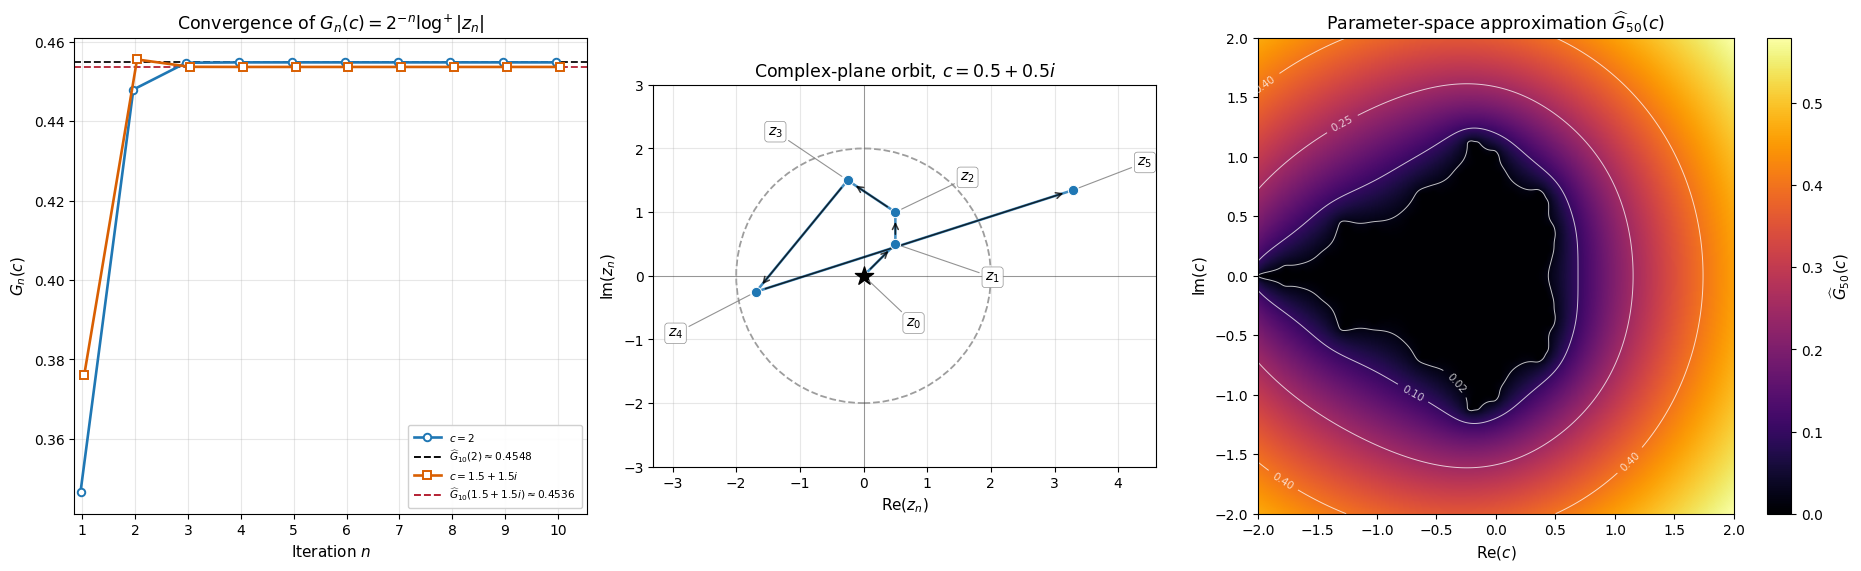

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

# ============================================================
# Figure 2: Three-panel numerical diagnostics
# Quadratic family: z_{n+1} = z_n^2 + c, z_0 = 0
# ============================================================

plt.rcParams.update({
    "font.size": 10.5,
    "axes.titlesize": 12.5,
    "axes.labelsize": 11,
    "legend.fontsize": 8.0,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


# ------------------------------------------------------------
# Basic orbit and escape-rate functions
# ------------------------------------------------------------

def critical_orbit(c, N):
    """
    Compute z_0,...,z_N for the quadratic critical orbit

        z_{n+1} = z_n^2 + c,   z_0 = 0.
    """
    z = np.zeros(N + 1, dtype=complex)

    for n in range(N):
        z[n + 1] = z[n]**2 + c

    return z


def log_plus_abs(z):
    """
    Compute log^+ |z| = max(log |z|, 0).
    """
    r = np.abs(z)
    out = np.zeros_like(r, dtype=float)

    mask = r > 0
    out[mask] = np.log(r[mask])

    return np.maximum(out, 0.0)


def finite_escape_approximants(c, N):
    """
    Compute

        G_n(c) = 2^{-n} log^+ |z_n|

    for n = 1,...,N.
    """
    z = critical_orbit(c, N)

    n_values = np.arange(1, N + 1)
    G_values = log_plus_abs(z[1:]) / (2.0 ** n_values)

    return n_values, G_values, z


# ------------------------------------------------------------
# Stable approximate Green-function heat map
# ------------------------------------------------------------

def escape_rate_grid(
    real_range=(-2, 2),
    imag_range=(-2, 2),
    grid_size=400,
    N=50,
    bailout=1e6
):
    """
    Compute a stable finite approximation to the escape-rate field.

    If a point crosses the bailout radius before N iterations, the plotted
    value is assigned using the regularized finite approximant at the escape
    index. This avoids overflow and gives a stable approximation to the
    Green-function-type escape-rate field.
    """
    real_vals = np.linspace(real_range[0], real_range[1], grid_size)
    imag_vals = np.linspace(imag_range[0], imag_range[1], grid_size)

    X, Y = np.meshgrid(real_vals, imag_vals)
    C = X + 1j * Y
    Z = np.zeros_like(C, dtype=complex)

    G = np.zeros_like(X, dtype=float)
    active = np.ones_like(X, dtype=bool)

    for n in range(1, N + 1):
        Z[active] = Z[active]**2 + C[active]
        R = np.abs(Z)

        escaped_now = active & (R > bailout)

        G[escaped_now] = np.log(R[escaped_now]) / (2.0 ** n)

        active[escaped_now] = False

        # Prevent overflow for already escaped points.
        Z[~active] = 0.0

    # Points not escaped by N are assigned their final finite approximation.
    R_final = np.abs(Z)
    G[active] = log_plus_abs(R_final[active]) / (2.0 ** N)

    return X, Y, G


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

N_main = 10
N_ref = 10

c_values = [
    2 + 0j,
    1.5 + 1.5j
]

labels = [
    r"$c=2$",
    r"$c=1.5+1.5i$"
]

parameter_names = [
    r"2",
    r"1.5+1.5i"
]


# ============================================================
# Build three-panel figure
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18.5, 5.6),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1.07, 1.05, 1.18]}
)


# ------------------------------------------------------------
# Panel 1: Convergence of G_n(c)
# ------------------------------------------------------------

ax = axes[0]

# Solid-curve colours
curve_colors = ["#1f77b4", "#d95f02"]      # blue, orange

# Marker choices are deliberately different
curve_markers = ["o", "s"]

# Dashed limiting reference-line colours
limit_line_colors = ["black", "#b2182b"]  # black, deep red

# Slight horizontal offsets for plotting only.
# This prevents nearly identical curves from covering each other.
# The underlying iteration index n is unchanged mathematically.
x_offsets = [-0.035, 0.035]

legend_handles = []

for k, (c, label, pname, color, marker) in enumerate(
    zip(c_values, labels, parameter_names, curve_colors, curve_markers)
):
    n_vals, G_vals, _ = finite_escape_approximants(c, N_main)
    _, G_ref_vals, _ = finite_escape_approximants(c, N_ref)

    G_hat = G_ref_vals[-1]

    # Visualization-only shifted x-values
    n_plot = n_vals + x_offsets[k]

    # Solid convergence curve
    ax.plot(
        n_plot,
        G_vals,
        marker=marker,
        markersize=5.4,
        markerfacecolor="white",
        markeredgewidth=1.4,
        linewidth=1.9,
        color=color,
        zorder=3 + k
    )

    # Dashed limiting horizontal reference line
    ax.axhline(
        G_hat,
        linestyle="--",
        linewidth=1.35,
        alpha=0.92,
        color=limit_line_colors[k],
        zorder=1
    )

    # Legend handle for convergence curve
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            marker=marker,
            markerfacecolor="white",
            markeredgewidth=1.4,
            linewidth=1.9,
            markersize=5.4,
            label=label
        )
    )

    # Legend handle for finite limiting estimate
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=limit_line_colors[k],
            linestyle="--",
            linewidth=1.35,
            label=fr"$\widehat{{G}}_{{{N_ref}}}({pname})\approx {G_hat:.4f}$"
        )
    )

ax.set_title(r"Convergence of $G_n(c)=2^{-n}\log^+|z_n|$")
ax.set_xlabel(r"Iteration $n$")
ax.set_ylabel(r"$G_n(c)$")

ax.grid(True, alpha=0.30)

ax.legend(
    handles=legend_handles,
    loc="lower right",
    framealpha=0.92,
    fontsize=7.6,
    handlelength=2.5,
    borderpad=0.6,
    labelspacing=0.45
)

# Keep integer tick labels even though points are slightly shifted visually
ax.set_xticks(np.arange(1, N_main + 1))
ax.set_xlim(0.85, N_main + 0.55)


# ------------------------------------------------------------
# Panel 2: Early complex-plane orbit evolution
# ------------------------------------------------------------

ax = axes[1]

c_orbit = 0.5 + 0.5j
N_orbit_plot = 5

z_orbit = critical_orbit(c_orbit, N_orbit_plot)

x = z_orbit.real
y = z_orbit.imag

# Reference disk |z|=2
circle = Circle(
    (0, 0),
    2,
    fill=False,
    linestyle="--",
    linewidth=1.3,
    alpha=0.65,
    color="dimgray"
)

ax.add_patch(circle)

# Discrete orbit
ax.plot(
    x,
    y,
    "-",
    color="#1f77b4",
    linewidth=1.85,
    alpha=0.84,
    zorder=2
)

ax.scatter(
    x,
    y,
    s=55,
    color="#1f77b4",
    edgecolor="white",
    linewidth=0.7,
    zorder=4
)

# Mark z_0
ax.scatter(
    [x[0]],
    [y[0]],
    marker="*",
    s=190,
    color="black",
    zorder=6
)

# Arrows between successive iterates
for n in range(len(z_orbit) - 1):
    ax.annotate(
        "",
        xy=(x[n + 1], y[n + 1]),
        xytext=(x[n], y[n]),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.15,
            color="black",
            alpha=0.75,
            shrinkA=7,
            shrinkB=7
        ),
        zorder=3
    )

# Non-overlapping label offsets
orbit_offsets = {
    0: (36, -34),
    1: (70, -24),
    2: (52, 25),
    3: (-52, 35),
    4: (-58, -30),
    5: (52, 20)
}

for n in range(len(z_orbit)):
    dx, dy = orbit_offsets[n]

    ax.annotate(
        fr"$z_{{{n}}}$",
        xy=(x[n], y[n]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10.2,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor="white",
            edgecolor="gray",
            linewidth=0.45,
            alpha=0.96
        ),
        arrowprops=dict(
            arrowstyle="-",
            color="gray",
            lw=0.8,
            alpha=0.85,
            shrinkA=2,
            shrinkB=5
        ),
        zorder=7
    )

z_orbit_check = critical_orbit(c_orbit, 6)



ax.set_title(r"Complex-plane orbit, $c=0.5+0.5i$")
ax.set_xlabel(r"$\operatorname{Re}(z_n)$")
ax.set_ylabel(r"$\operatorname{Im}(z_n)$")

ax.axhline(0, color="black", linewidth=0.75, alpha=0.35)
ax.axvline(0, color="black", linewidth=0.75, alpha=0.35)

ax.grid(True, alpha=0.30)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-3.3, 4.6)
ax.set_ylim(-3, 3)


# ------------------------------------------------------------
# Panel 3: Parameter-space approximation heat map
# ------------------------------------------------------------

ax = axes[2]

N_heat = 50

X, Y, G_grid = escape_rate_grid(
    real_range=(-2, 2),
    imag_range=(-2, 2),
    grid_size=400,
    N=N_heat,
    bailout=1e6
)

# Heat map of the finite/stabilized escape-rate approximation
im = ax.imshow(
    G_grid,
    extent=[-2, 2, -2, 2],
    origin="lower",
    cmap="inferno",
    aspect="equal"
)

# ------------------------------------------------------------
# Equipotential contour curves
# ------------------------------------------------------------

contour_levels = [0.02, 0.10, 0.25, 0.40]

cs = ax.contour(
    X,
    Y,
    G_grid,
    levels=contour_levels,
    colors="white",
    linewidths=0.70,
    alpha=0.75
)

# Keep contour labels
ax.clabel(
    cs,
    inline=True,
    fontsize=7.5,
    fmt="%.2f",
    colors="white"
)

# ------------------------------------------------------------
# Colour bar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    fr"$\widehat{{G}}_{{{N_heat}}}(c)$"
)

# ------------------------------------------------------------
# Axis labels and title
# ------------------------------------------------------------

ax.set_title(
    fr"Parameter-space approximation $\widehat{{G}}_{{{N_heat}}}(c)$"
)

ax.set_xlabel(r"$\operatorname{Re}(c)$")
ax.set_ylabel(r"$\operatorname{Im}(c)$")


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.savefig(
    "figure2_three_panel_diagnostics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "figure2_three_panel_diagnostics.pdf",
    bbox_inches="tight"
)

plt.show()

# Numerical Diagnostics for the Regularized Escape-Rate Function

This code implements the numerical diagnostic framework for the quadratic family

$$
f_c(z)=z^2+c,
\qquad
c\in\mathbb C,
$$

using the critical orbit

$$
z_0=0,
\qquad
z_{n+1}=z_n^2+c.
$$

The main quantity computed by the code is the finite regularized escape-rate approximant

$$
G_n(c)=\frac{\log^+|z_n|}{2^n},
$$

where

$$
\log^+ r=\max\{\log r,0\}.
$$

For escaping parameters $c\notin\mathcal M$, the finite approximants $G_n(c)$ stabilize toward the escape-rate function

$$
G(c)=\lim_{n\to\infty}G_n(c).
$$

For bounded parameters $c\in\mathcal M$, the critical orbit remains bounded and

$$
G_n(c)\to 0.
$$

Thus the same computational framework distinguishes bounded and escaping parameters while producing a stable numerical approximation of the escape-rate field.

---

## Mathematical Motivation

For escaping parameters, the raw orbit magnitude $|z_n|$ may grow extremely rapidly. Once the orbit is sufficiently large, the quadratic term dominates:

$$
|z_{n+1}|\approx |z_n|^2.
$$

Taking logarithms gives

$$
\log|z_{n+1}|
\approx
2\log|z_n|.
$$

Therefore, the natural logarithmic scale after $n$ iterations is $2^n$. This explains the normalization

$$
G_n(c)=2^{-n}\log^+|z_n|.
$$

The theoretical asymptotic law is

$$
\log|z_n|
=
2^nG(c)+o(2^n),
$$

or equivalently,

$$
|z_n|
=
\exp\!\left(2^nG(c)+o(2^n)\right).
$$

The Python code numerically demonstrates this stabilization by computing and plotting $G_n(c)$ for selected escaping parameters.

---

## Core Computational Idea

The essential computation is:

```python
import numpy as np

def log_plus(r):
    return np.maximum(np.log(np.maximum(r, 1e-300)), 0.0)

def compute_G_values(c, N):
    z = 0 + 0j
    G_values = []

    for n in range(1, N + 1):
        z = z**2 + c
        G_n = log_plus(abs(z)) / (2.0**n)
        G_values.append(G_n)

    return np.array(G_values)
```

This short code block performs the core algorithm:

1. start with $z_0=0$;
2. iterate $z_{n+1}=z_n^2+c$;
3. compute $\log^+|z_n|$;
4. divide by $2^n$;
5. store the values $G_n(c)$.

The full code extends this basic computation into a three-panel numerical diagnostic figure.

---

## Functions Used in the Full Code

The full Python code is organized around three main functions.

### 1. Critical Orbit Function

```python
critical_orbit(c, N)
```

This computes the finite orbit

$$
z_0,z_1,\ldots,z_N
$$

using

$$
z_{n+1}=z_n^2+c.
$$

Mathematically, this returns

$$
z_n(c)=f_c^{\circ n}(0),
\qquad
0\leq n\leq N.
$$

---

### 2. Finite Escape-Rate Function

```python
finite_escape_approximants(c, N)
```

This computes

$$
G_n(c)=\frac{\log^+|z_n|}{2^n},
\qquad
1\leq n\leq N.
$$

It returns the finite sequence

$$
G_1(c),G_2(c),\ldots,G_N(c).
$$

For escaping parameters, this sequence stabilizes toward $G(c)$.

---

### 3. Parameter-Space Grid Function

```python
escape_rate_grid(real_range, imag_range, grid_size, N, bailout)
```

This computes a stabilized finite approximation over a grid of parameters

$$
c=x+iy.
$$

For each grid point, the code iterates

$$
z_{n+1}=z_n^2+c.
$$

If the orbit crosses a bailout radius $B$ at iteration $\tau$, the code records

$$
\widehat G_N(c)=\frac{\log|z_\tau|}{2^\tau}.
$$

If the orbit does not cross the bailout radius within $N$ iterations, it records

$$
\widehat G_N(c)=\frac{\log^+|z_N|}{2^N}.
$$

This stabilized approximation prevents numerical overflow while preserving the normalized logarithmic scale.

---

## Algorithmic Summary

```text
Algorithm: Three-Panel Escape-Rate Diagnostics

Input:
    selected escaping parameters c_1 and c_2
    orbit parameter c_orbit
    maximum iteration count N
    heat-map iteration count N_heat
    bailout radius B
    parameter grid Omega

Step 1:
    For each selected parameter c_j:
        set z_0 = 0
        iterate z_{n+1}=z_n^2+c_j
        compute G_n(c_j)=2^{-n} log^+ |z_n|

Step 2:
    Plot G_n(c_j) against n
    add finite reference lines using G_N(c_j)

Step 3:
    For the orbit parameter c_orbit:
        compute z_0,z_1,...,z_N
        plot the orbit in the complex plane
        draw arrows z_n -> z_{n+1}

Step 4:
    For each grid parameter c=x+iy:
        set z_0=0
        iterate z_{n+1}=z_n^2+c

        if |z_n| exceeds the bailout radius:
            assign log|z_n|/2^n
            stop iterating that grid point

        otherwise:
            after N_heat iterations assign log^+|z_N|/2^N

Step 5:
    Plot the stabilized parameter-space approximation
    overlay contour curves as approximate equipotentials

Output:
    A three-panel figure showing convergence,
    orbit geometry, and parameter-space escape-rate structure.
```

---

## Interpretation of the Three Panels

The generated figure contains three complementary diagnostics.

### Panel 1: Convergence of $G_n(c)$

The first panel plots

$$
G_n(c)=2^{-n}\log^+|z_n|
$$

for selected escaping parameters, such as

$$
c=2
$$

and

$$
c=1.5+1.5i.
$$

The dashed horizontal lines show finite reference values such as

$$
\widehat G_{10}(c)=G_{10}(c).
$$

This panel illustrates the numerical stabilization

$$
G_n(c)\to G(c).
$$

It also shows that different escaping parameters generally converge to different limiting values. Therefore, $G(c)$ is parameter-dependent and is not a universal constant.

---

### Panel 2: Complex-Plane Orbit Geometry

The second panel plots a short segment of the critical orbit for a sample parameter such as

$$
c=0.5+0.5i.
$$

The plotted points are

$$
z_0,z_1,\ldots,z_5.
$$

The arrows represent the discrete iteration

$$
z_n\mapsto z_{n+1}.
$$

The dashed circle marks the reference radius

$$
|z|=2.
$$

This panel shows the early complex-plane geometry of the critical orbit before later iterates become too large to display clearly.

---

### Panel 3: Parameter-Space Approximation

The third panel computes the stabilized finite approximation

$$
\widehat G_{50}(c)
$$

over a grid of complex parameters

$$
c=x+iy.
$$

Dark regions correspond to values close to zero and approximate the bounded region associated with the Mandelbrot set.

Bright regions correspond to escaping parameters with positive escape-rate values.

The contour curves approximate equipotential curves, or level sets of the form

$$
G(c)=\alpha.
$$

Thus the heat map gives a finite numerical visualization of the escape-rate field over parameter space.

---

## Why the Code Is Mathematically Justified

The code is justified by the following mathematical facts:

1. The recurrence

$$
z_{n+1}=z_n^2+c
$$

is the critical orbit of the quadratic family.

2. The finite approximants

$$
G_n(c)=\frac{\log^+|z_n|}{2^n}
$$

are the normalized quantities whose limit defines the escape-rate function.

3. The factor $2^n$ appears because the map has degree $2$ and repeated squaring doubles the logarithmic scale at each iteration.

4. For escaping parameters,

$$
G_n(c)\to G(c).
$$

5. For bounded parameters,

$$
G_n(c)\to 0.
$$

6. The stabilized grid approximation $\widehat G_N(c)$ avoids overflow while preserving the normalized logarithmic scale.

Therefore, the Python code is a computational realization of the mathematical regularization framework.

---

## Numerical Meaning of $\widehat G_N(c)$

The stabilized approximation $\widehat G_N(c)$ is used for visualization.

If a parameter escapes before the maximum iteration count, the approximation is recorded at the first escape index $\tau$:

$$
\widehat G_N(c)=\frac{\log|z_\tau|}{2^\tau}.
$$

If no escape is detected by the maximum iteration count, the final finite approximant is used:

$$
\widehat G_N(c)=\frac{\log^+|z_N|}{2^N}.
$$

This approach keeps the calculation stable and avoids overflow in the parameter-space heat map.

---

## Connection with the Research Manuscript

The manuscript distinguishes three related quantities:

$$
G_n(c),
\qquad
\widehat G_N(c),
\qquad
G(c).
$$

The Python code implements all three numerically:

- $G_n(c)$ is computed for selected parameters and plotted as convergence curves.
- $\widehat G_N(c)$ is computed over a grid to visualize the parameter-space field.
- $G(c)$ is approximated by the stabilization of $G_n(c)$.

Thus the code provides a computational bridge between the theoretical escape-rate construction and the numerical figures in the manuscript.

In summary, the code shows how logarithmic normalization converts explosive orbit growth into a finite, stable, and geometrically meaningful parameter-space quantity.

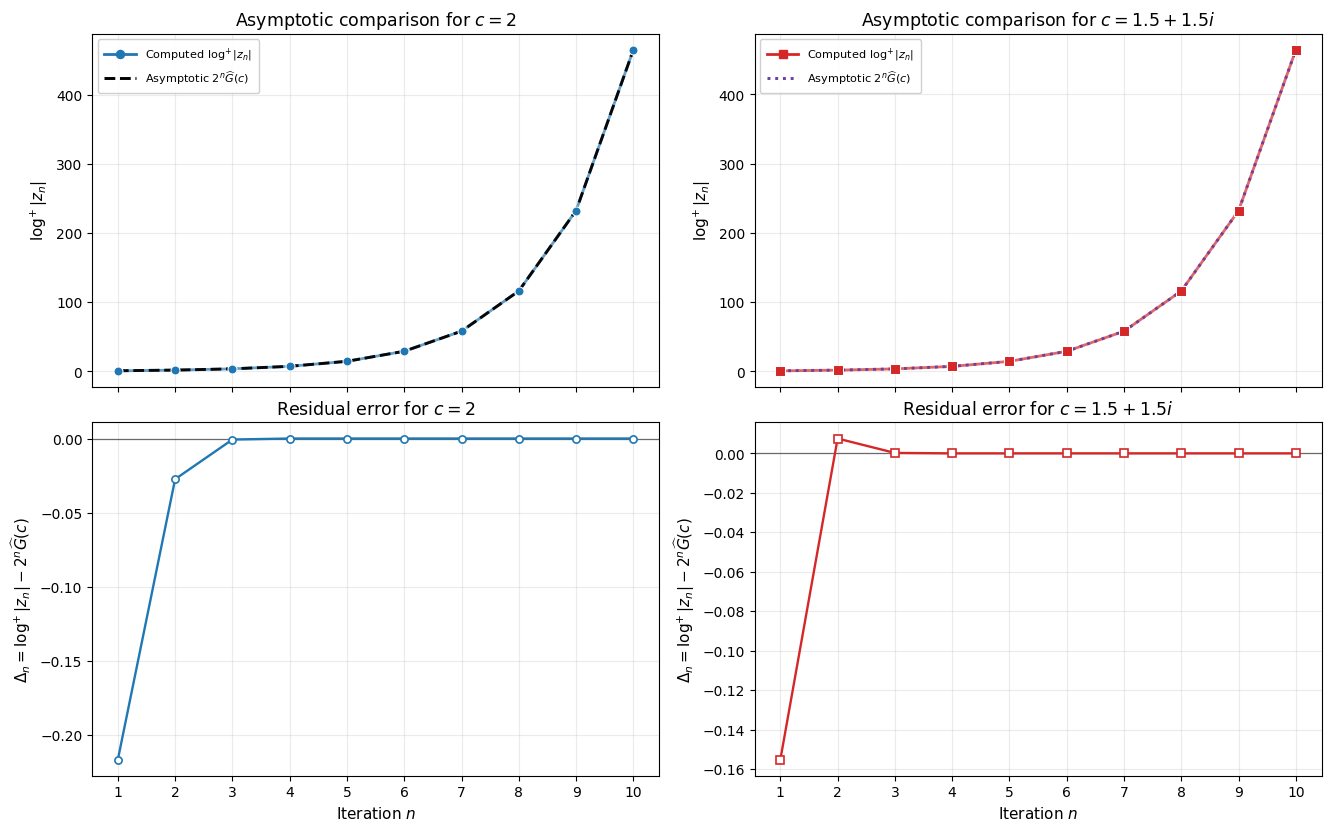

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Asymptotic growth diagnostic
# Quadratic family: z_{n+1}=z_n^2+c, z_0=0
# ============================================================

plt.rcParams.update({
    "font.size": 10.5,
    "axes.titlesize": 12.5,
    "axes.labelsize": 11,
    "legend.fontsize": 8.2,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


# ------------------------------------------------------------
# Basic orbit and escape-rate functions
# ------------------------------------------------------------

def critical_orbit(c, N):
    """
    Compute z_0,...,z_N for z_{n+1}=z_n^2+c, z_0=0.
    """
    z = np.zeros(N + 1, dtype=complex)

    for n in range(N):
        z[n + 1] = z[n]**2 + c

    return z


def log_plus_abs(z):
    """
    Compute log^+ |z| = max(log |z|,0).
    """
    r = np.abs(z)
    out = np.zeros_like(r, dtype=float)

    mask = r > 0
    out[mask] = np.log(r[mask])

    return np.maximum(out, 0.0)


def finite_escape_approximants(c, N):
    """
    Compute G_n(c)=2^{-n}log^+|z_n| for n=1,...,N.
    """
    z = critical_orbit(c, N)
    n_values = np.arange(1, N + 1)
    G_values = log_plus_abs(z[1:]) / (2.0 ** n_values)

    return n_values, G_values, z


def logarithmic_growth(c, N):
    """
    Compute log^+|z_n| for n=1,...,N.
    """
    z = critical_orbit(c, N)
    n_values = np.arange(1, N + 1)
    log_values = log_plus_abs(z[1:])

    return n_values, log_values, z


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

N_main = 10
N_ref = 10

c_values = [
    2 + 0j,
    1.5 + 1.5j
]

labels = [
    r"$c=2$",
    r"$c=1.5+1.5i$"
]

actual_colors = ["#1f77b4", "#d62728"]      # blue, red
model_colors = ["black", "#6a3d9a"]         # black, purple
actual_markers = ["o", "s"]
model_styles = ["--", ":"]


# ============================================================
# Build publication-ready asymptotic-growth figure
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13.2, 8.2),
    constrained_layout=True,
    sharex=True
)

for k, (c, label) in enumerate(zip(c_values, labels)):

    # Compute logarithmic growth and finite approximation
    n_vals, log_vals, _ = logarithmic_growth(c, N_main)
    _, G_ref_vals, _ = finite_escape_approximants(c, N_ref)

    G_hat = G_ref_vals[-1]

    # Asymptotic comparison curve
    asymptotic_curve = (2.0 ** n_vals) * G_hat

    # Residual:
    # Delta_n = log^+|z_n| - 2^n Ghat(c)
    residual = log_vals - asymptotic_curve

    # --------------------------------------------------------
    # Top row: computed logarithmic growth vs asymptotic model
    # --------------------------------------------------------

    ax_top = axes[0, k]

    # Actual computed logarithmic growth
    ax_top.plot(
        n_vals,
        log_vals,
        color=actual_colors[k],
        linestyle="-",
        linewidth=2.0,
        alpha=0.70,
        zorder=2
    )

    ax_top.scatter(
        n_vals,
        log_vals,
        color=actual_colors[k],
        marker=actual_markers[k],
        s=42,
        edgecolor="white",
        linewidth=0.75,
        zorder=5
    )

    # Asymptotic model
    ax_top.plot(
        n_vals,
        asymptotic_curve,
        color=model_colors[k],
        linestyle=model_styles[k],
        linewidth=2.1,
        alpha=0.95,
        zorder=4
    )

    ax_top.set_title(
        fr"Asymptotic comparison for {label}"
    )

    ax_top.set_ylabel(r"$\log^+|z_n|$")
    ax_top.grid(True, alpha=0.25)

    # Manual legend for clarity
    legend_handles = [
        Line2D(
            [0],
            [0],
            color=actual_colors[k],
            marker=actual_markers[k],
            linestyle="-",
            linewidth=2.0,
            markersize=5.8,
            label=fr"Computed $\log^+|z_n|$"
        ),
        Line2D(
            [0],
            [0],
            color=model_colors[k],
            linestyle=model_styles[k],
            linewidth=2.1,
            label=fr"Asymptotic $2^n\widehat{{G}}(c)$"
        )
    ]

    ax_top.legend(
        handles=legend_handles,
        loc="upper left",
        framealpha=0.92,
        fontsize=8.1,
        handlelength=2.8,
        borderpad=0.6
    )

    # --------------------------------------------------------
    # Bottom row: residual / error term
    # --------------------------------------------------------

    ax_bottom = axes[1, k]

    ax_bottom.axhline(
        0,
        color="black",
        linewidth=0.9,
        alpha=0.55
    )

    ax_bottom.plot(
        n_vals,
        residual,
        color=actual_colors[k],
        marker=actual_markers[k],
        markersize=5.2,
        markerfacecolor="white",
        markeredgewidth=1.2,
        linewidth=1.7,
        zorder=3
    )

    ax_bottom.set_xlabel(r"Iteration $n$")
    ax_bottom.set_ylabel(
        r"$\Delta_n=\log^+|z_n|-2^n\widehat{G}(c)$"
    )

    ax_bottom.grid(True, alpha=0.25)

    ax_bottom.set_title(
        fr"Residual error for {label}"
    )

    # Keep integer iteration ticks
    ax_bottom.set_xticks(np.arange(1, N_main + 1))


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.savefig(
    "figure_asymptotic_growth_diagnostic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "figure_asymptotic_growth_diagnostic.pdf",
    bbox_inches="tight"
)

plt.show()

# Asymptotic Growth Diagnostic for the Regularized Escape Rate

This section implements the numerical diagnostic used to test the asymptotic growth law for escaping critical orbits in the quadratic family

$$
f_c(z)=z^2+c,
\qquad
c\in\mathbb C.
$$

Starting from the critical point

$$
z_0=0,
$$

we iterate

$$
z_{n+1}=z_n^2+c.
$$

The aim of this code is to compare the computed logarithmic growth

$$
\log^+|z_n|
$$

with the finite asymptotic model

$$
2^n\widehat G(c),
$$

where $\widehat G(c)$ is a high-iteration finite approximation to the limiting escape-rate value $G(c)$.

In the manuscript, the theoretical asymptotic relation is

$$
\log|z_n|
=
2^nG(c)+o(2^n).
$$

Therefore, this numerical diagnostic checks whether the computed orbit follows the leading model $2^nG(c)$ and whether the remaining discrepancy behaves like a lower-order residual.

---

## Mathematical Quantity Being Tested

The finite escape-rate approximants are

$$
G_n(c)=\frac{\log^+|z_n|}{2^n}.
$$

For escaping parameters $c\notin\mathcal M$, these approximants converge to

$$
G(c)=\lim_{n\to\infty}G_n(c).
$$

In the code, a finite reference value is chosen as

$$
\widehat G_{N_{\mathrm{ref}}}(c)=G_{N_{\mathrm{ref}}}(c).
$$

In this implementation,

$$
N_{\mathrm{ref}}=10.
$$

Thus the finite model for logarithmic growth is

$$
2^n\widehat G_{10}(c).
$$

This model is compared with the computed quantity

$$
\log^+|z_n|.
$$

---

## Residual Error

The residual is defined by

$$
\Delta_n(c)
=
\log^+|z_n|-2^n\widehat G_{10}(c).
$$

This residual measures how far the computed logarithmic growth is from the finite asymptotic model.

If the asymptotic relation

$$
\log|z_n|
=
2^nG(c)+o(2^n)
$$

is numerically reflected in the orbit, then the residual should be small relative to the leading term

$$
2^n\widehat G_{10}(c).
$$

Thus the residual plot makes visible the lower-order term hidden in the notation $o(2^n)$.

---

## Core Computational Idea

The essential numerical computation is:

```python
import numpy as np

def log_plus(r):
    return np.maximum(np.log(np.maximum(r, 1e-300)), 0.0)

def asymptotic_growth_diagnostic(c, N, N_ref):
    z = 0 + 0j
    log_values = []
    G_values = []

    for n in range(1, N + 1):
        z = z**2 + c
        L_n = log_plus(abs(z))
        G_n = L_n / (2.0**n)

        log_values.append(L_n)
        G_values.append(G_n)

    log_values = np.array(log_values)
    G_values = np.array(G_values)

    G_hat = G_values[N_ref - 1]

    n_values = np.arange(1, N + 1)

    asymptotic_model = (2.0**n_values) * G_hat

    residual = log_values - asymptotic_model

    return n_values, log_values, asymptotic_model, residual
```

This short code block captures the main logic:

1. compute the critical orbit;
2. compute $\log^+|z_n|$;
3. compute $G_n(c)$;
4. choose $\widehat G_{N_{\mathrm{ref}}}(c)$ as a finite reference;
5. form the asymptotic model $2^n\widehat G(c)$;
6. compute the residual $\Delta_n(c)$.

The full code extends this core computation into a publication-style two-row figure.
---

## Functions Used in the Full Code

The full Python code is organized around four main functions.

---

### 1. Critical Orbit Function

```python
critical_orbit(c, N)
```

This function computes the finite critical orbit

$$
z_0,z_1,\ldots,z_N
$$

using the recurrence relation

$$
z_{n+1}=z_n^2+c.
$$

This is the computational realization of the critical orbit

$$
z_n(c)=f_c^{\circ n}(0).
$$

---

### 2. Positive Logarithm Function

```python
log_plus_abs(z)
```

This function computes

$$
\log^+|z|
=
\max\{\log|z|,0\}.
$$

The positive logarithm is used because early orbit values may satisfy $|z_n|\leq 1$. In that case, $\log|z_n|$ would be negative, but the escape-rate formalism uses the nonnegative quantity

$$
\log^+|z_n|.
$$

---

### 3. Finite Escape-Rate Approximants

```python
finite_escape_approximants(c, N)
```

This function computes

$$
G_n(c)=\frac{\log^+|z_n|}{2^n},
\qquad
1\leq n\leq N.
$$

The final value

$$
G_{N_{\mathrm{ref}}}(c)
$$

is used as the finite reference approximation

$$
\widehat G(c).
$$

---

### 4. Logarithmic Growth Function

```python
logarithmic_growth(c, N)
```

This function computes the sequence

$$
\log^+|z_1|,
\log^+|z_2|,
\ldots,
\log^+|z_N|.
$$

This is the directly observed logarithmic growth of the critical orbit.

---

## Algorithmic Summary

```text
Algorithm: Asymptotic Growth and Residual Diagnostic

Input:
    escaping parameter c
    main iteration count N
    reference iteration count N_ref

Step 1:
    Set z_0 = 0.

Step 2:
    For n = 1 to N:
        compute z_n = z_{n-1}^2 + c
        compute L_n = log^+ |z_n|
        compute G_n(c) = L_n / 2^n

Step 3:
    Set the finite reference estimate
        G_hat(c) = G_{N_ref}(c)

Step 4:
    For each n:
        compute the asymptotic model
            A_n(c) = 2^n G_hat(c)

Step 5:
    Compute the residual
        Delta_n(c) = L_n - A_n(c)

Step 6:
    Plot:
        top row: L_n versus A_n(c)
        bottom row: Delta_n(c)

Output:
    A two-row diagnostic figure comparing computed logarithmic growth
    with the finite asymptotic model and displaying the residual error.
```

---

## Interpretation of the Generated Figure

The generated figure has two rows and two columns.

The two columns correspond to two escaping parameters, such as

$$
c=2
$$

and

$$
c=1.5+1.5i.
$$

---

### Top Row: Logarithmic Growth versus Asymptotic Model

The top row compares the computed logarithmic growth

$$
\log^+|z_n|
$$

with the finite asymptotic model

$$
2^n\widehat G(c).
$$

If the theory is reflected numerically, the two curves should closely follow each other after the early transient stage.

This illustrates the leading growth law

$$
\log|z_n|
\approx
2^nG(c).
$$

---

### Bottom Row: Residual Error

The bottom row plots the residual

$$
\Delta_n(c)
=
\log^+|z_n|-2^n\widehat G(c).
$$

This residual shows the difference between the computed logarithmic growth and the finite leading-order model.

The purpose of the residual plot is to make the lower-order discrepancy visible. In the asymptotic statement

$$
\log|z_n|
=
2^nG(c)+o(2^n),
$$

the term $o(2^n)$ is not visible in the leading-order plot. The residual plot exposes this lower-order behaviour.

---

## Why This Code Is Mathematically Justified

The code is justified by the asymptotic interpretation of the escape-rate function.

For escaping parameters,

$$
G_n(c)
=
\frac{\log^+|z_n|}{2^n}
\to
G(c).
$$

Therefore, for a sufficiently large reference index $N_{\mathrm{ref}}$,

$$
\widehat G(c)=G_{N_{\mathrm{ref}}}(c)
$$

acts as a finite numerical approximation to $G(c)$.

Substituting this approximation into the leading asymptotic law gives the finite model

$$
\log^+|z_n|
\approx
2^n\widehat G(c).
$$

The code tests this approximation visually and numerically.

The residual

$$
\Delta_n(c)
=
\log^+|z_n|-2^n\widehat G(c)
$$

then approximates the lower-order error in the asymptotic formula.

Thus the code directly supports the manuscript’s mathematical statement

$$
\log|z_n|
=
2^nG(c)+o(2^n).
$$

---

## Numerical Meaning of the Residual

The residual is not a certified error bound. Instead, it is a numerical diagnostic.

The certified error bound in the manuscript controls

$$
|G(c)-G_n(c)|.
$$

By contrast, the residual plot shows the difference

$$
\log^+|z_n|-2^n\widehat G(c).
$$

Thus the residual is used to visualize the lower-order term in the asymptotic expansion, not to provide a rigorous stopping certificate.

This distinction is important:

- the certified error bound is used for rigorous approximation of $G(c)$;
- the residual diagnostic is used to visualize the asymptotic growth law.

---

## Connection with the Research Manuscript

This code corresponds to the asymptotic-growth diagnostic figure in the manuscript.

The manuscript proves that, for escaping parameters,

$$
\log|z_n|
=
2^nG(c)+o(2^n).
$$

The code tests this statement numerically by comparing

$$
\log^+|z_n|
$$

with

$$
2^n\widehat G(c).
$$

The top row checks the leading asymptotic agreement.

The bottom row displays the residual error.

In this way, the Python code provides a computational visualization of the asymptotic meaning of the regularized escape-rate function.

---

## Summary

This diagnostic has three main purposes:

1. It verifies that the computed logarithmic growth follows the model

$$
2^n\widehat G(c).
$$

2. It illustrates the asymptotic law

$$
\log|z_n|
=
2^nG(c)+o(2^n).
$$

3. It visualizes the residual lower-order term

$$
\Delta_n(c)
=
\log^+|z_n|-2^n\widehat G(c).
$$

Therefore, this code connects the theoretical asymptotic result with a concrete numerical experiment.


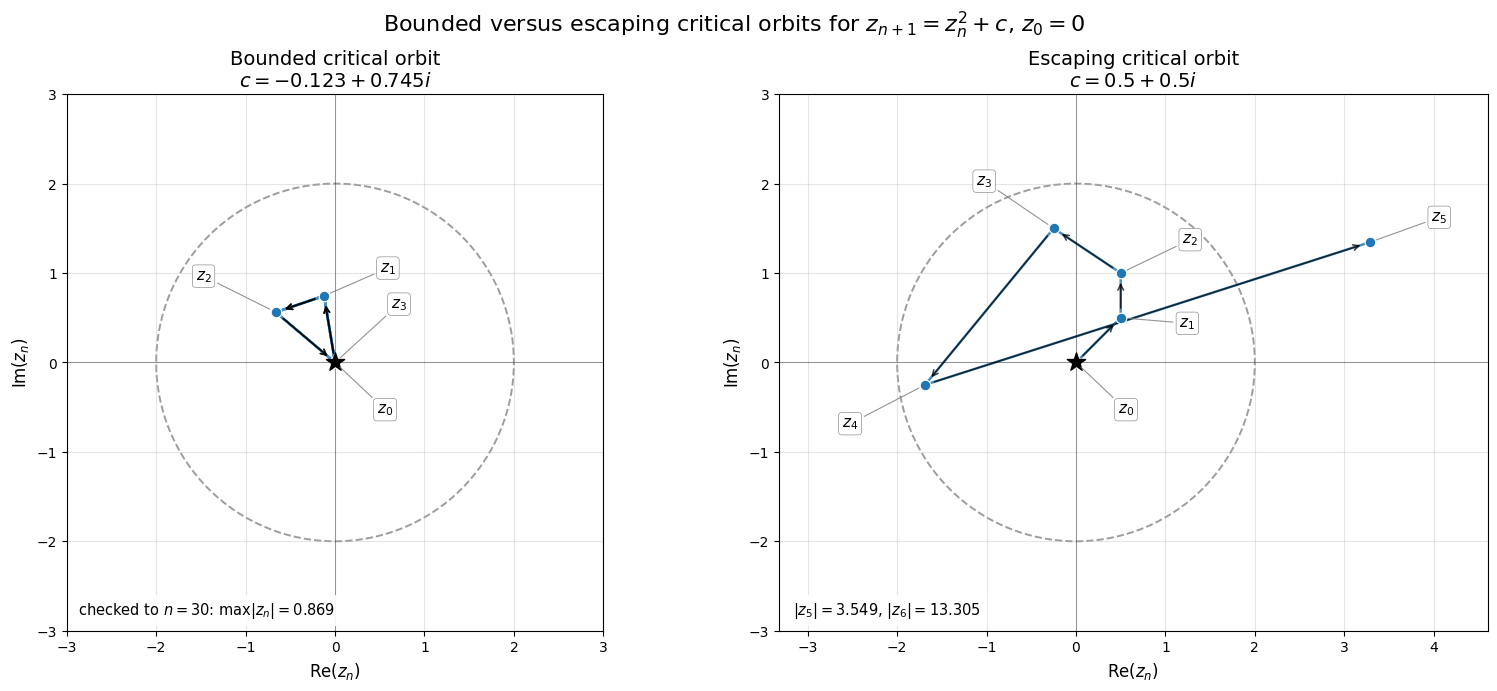

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ------------------------------------------------------------
# Figure 1: Bounded vs escaping critical-orbit behaviour
# Quadratic family: z_{n+1} = z_n^2 + c, z_0 = 0
# Publication-ready version with non-overlapping annotations
# ------------------------------------------------------------

def critical_orbit(c, N):
    """
    Return z_0,...,z_N for the quadratic critical orbit

        z_{n+1} = z_n^2 + c,   z_0 = 0.
    """
    z = np.zeros(N + 1, dtype=complex)

    for n in range(N):
        z[n + 1] = z[n]**2 + c

    return z


# ------------------------------------------------------------
# Parameter choices
# ------------------------------------------------------------

# Bounded parameter: nontrivial bounded critical orbit
c_bounded = -0.123 + 0.745j

# Compute enough terms to verify boundedness
N_bounded_check = 30
z_bounded_check = critical_orbit(c_bounded, N_bounded_check)

# Plot only enough terms to show the bounded pattern clearly
N_bounded_plot = 8
z_bounded = critical_orbit(c_bounded, N_bounded_plot)


# Escaping parameter: early non-radial motion remains visible
c_escape = 0.5 + 0.5j

# Plot only up to z_5. z_6 is already much farther away and would distort scaling.
N_escape_plot = 5
z_escape = critical_orbit(c_escape, N_escape_plot)

# Compute one extra iterate for the annotation
z_escape_check = critical_orbit(c_escape, 6)


# ------------------------------------------------------------
# Label choices
# ------------------------------------------------------------

# For the bounded orbit, do not label every point.
# z_0,z_1,z_2,z_3 already show the bounded repeating structure.
bounded_label_indices = [0, 1, 2, 3]

bounded_label_offsets = {
    0: (36, -34),
    1: (46, 20),
    2: (-52, 26),
    3: (46, 42)
}

# For the escaping orbit, label the visible early escape sequence.
escape_label_indices = [0, 1, 2, 3, 4, 5]

escape_label_offsets = {
    0: (36, -34),
    1: (48, -4),
    2: (50, 24),
    3: (-50, 34),
    4: (-54, -28),
    5: (50, 18)
}


# ------------------------------------------------------------
# Plotting helper
# ------------------------------------------------------------

def plot_discrete_orbit(
    ax,
    z,
    c,
    title,
    disk_radius=2,
    label_indices=None,
    label_offsets=None,
    annotation_text=None,
    show_unlabelled_points=True
):
    """
    Plot a discrete critical orbit in the complex plane.

    The visualization follows the mathematics:
    - points are actual iterates z_0,z_1,...
    - arrows show z_n -> z_{n+1}
    - no smooth interpolation is used
    - only mathematically necessary labels are displayed
    """

    if label_indices is None:
        label_indices = range(len(z))

    if label_offsets is None:
        label_offsets = {}

    x = z.real
    y = z.imag

    # Reference disk |z| = 2
    circle = Circle(
        (0, 0),
        disk_radius,
        fill=False,
        linestyle='--',
        linewidth=1.4,
        alpha=0.65,
        color='dimgray'
    )
    ax.add_patch(circle)

    # Discrete orbit: straight segments only
    ax.plot(
        x,
        y,
        '-',
        color='tab:blue',
        linewidth=1.8,
        alpha=0.82,
        zorder=2
    )

    # All orbit points
    if show_unlabelled_points:
        ax.scatter(
            x,
            y,
            s=44,
            color='tab:blue',
            edgecolor='white',
            linewidth=0.6,
            zorder=4
        )

    # Highlight labelled points slightly
    ax.scatter(
        x[label_indices],
        y[label_indices],
        s=58,
        color='tab:blue',
        edgecolor='white',
        linewidth=0.8,
        zorder=5
    )

    # Mark z_0 distinctly
    ax.scatter(
        [x[0]],
        [y[0]],
        marker='*',
        s=190,
        color='black',
        zorder=6
    )

    # Direction arrows between true successive iterates
    for n in range(len(z) - 1):
        ax.annotate(
            '',
            xy=(x[n + 1], y[n + 1]),
            xytext=(x[n], y[n]),
            arrowprops=dict(
                arrowstyle='->',
                lw=1.15,
                color='black',
                alpha=0.75,
                shrinkA=7,
                shrinkB=7
            ),
            zorder=3
        )

    # Clear labels with leader lines
    for n in label_indices:
        dx, dy = label_offsets.get(n, (35, 20))

        ax.annotate(
            fr'$z_{{{n}}}$',
            xy=(x[n], y[n]),
            xytext=(dx, dy),
            textcoords='offset points',
            fontsize=11,
            ha='center',
            va='center',
            bbox=dict(
                boxstyle='round,pad=0.22',
                facecolor='white',
                edgecolor='gray',
                linewidth=0.45,
                alpha=0.96
            ),
            arrowprops=dict(
                arrowstyle='-',
                color='gray',
                lw=0.8,
                alpha=0.85,
                shrinkA=2,
                shrinkB=5
            ),
            zorder=7
        )

    # Mathematical annotation inside panel
    if annotation_text is not None:
        ax.text(
            0.02,
            0.03,
            annotation_text,
            transform=ax.transAxes,
            fontsize=10.5,
            bbox=dict(
                facecolor='white',
                alpha=0.90,
                edgecolor='none'
            )
        )

    ax.set_title(
        title + '\n' + fr'$c={c.real:.3g}{c.imag:+.3g}i$',
        fontsize=14
    )

    ax.set_xlabel(r'$\operatorname{Re}(z_n)$', fontsize=12)
    ax.set_ylabel(r'$\operatorname{Im}(z_n)$', fontsize=12)

    ax.axhline(0, color='black', linewidth=0.75, alpha=0.35)
    ax.axvline(0, color='black', linewidth=0.75, alpha=0.35)

    ax.grid(True, alpha=0.32)
    ax.set_aspect('equal', adjustable='box')

    # Axis limits with generous padding for label boxes
    xmin = min(np.min(x), -disk_radius)
    xmax = max(np.max(x), disk_radius)
    ymin = min(np.min(y), -disk_radius)
    ymax = max(np.max(y), disk_radius)

    pad_x = 0.25 * max(1e-9, xmax - xmin)
    pad_y = 0.25 * max(1e-9, ymax - ymin)

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)


# ------------------------------------------------------------
# Generate figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15.5, 6.8),
    constrained_layout=True
)

# Left panel: bounded orbit
plot_discrete_orbit(
    axes[0],
    z_bounded,
    c_bounded,
    title='Bounded critical orbit',
    disk_radius=2,
    label_indices=bounded_label_indices,
    label_offsets=bounded_label_offsets,
    annotation_text=(
        fr'checked to $n={N_bounded_check}$: '
        fr'$\max |z_n|={np.max(np.abs(z_bounded_check)):.3f}$'
    )
)

# Right panel: escaping orbit
plot_discrete_orbit(
    axes[1],
    z_escape,
    c_escape,
    title='Escaping critical orbit',
    disk_radius=2,
    label_indices=escape_label_indices,
    label_offsets=escape_label_offsets,
    annotation_text=(
        fr'$|z_5|={abs(z_escape_check[5]):.3f}$, '
        fr'$|z_6|={abs(z_escape_check[6]):.3f}$'
    )
)

fig.suptitle(
    r'Bounded versus escaping critical orbits for '
    r'$z_{n+1}=z_n^2+c$, $z_0=0$',
    fontsize=16
)

# Save figure
plt.savefig(
    'figure1_publication_bounded_vs_escaping.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'figure1_publication_bounded_vs_escaping.pdf',
    bbox_inches='tight'
)

plt.show()

# Bounded versus Escaping Critical-Orbit Behaviour

This section visualizes the two fundamental dynamical regimes of the quadratic family

$$
f_c(z)=z^2+c,
\qquad
c\in\mathbb C.
$$

Starting from the critical point

$$
z_0=0,
$$

the critical orbit is generated by

$$
z_{n+1}=z_n^2+c.
$$

The behaviour of this orbit determines whether the parameter $c$ belongs to the Mandelbrot set. If the critical orbit remains bounded, then

$$
c\in\mathcal M.
$$

If the critical orbit escapes to infinity, then

$$
c\notin\mathcal M.
$$

The purpose of this code is to visualize these two behaviours side by side:

1. a bounded critical orbit;
2. an escaping critical orbit.

This figure provides the geometric motivation for replacing the raw orbit magnitude $|z_n|$ by the regularized finite approximants

$$
G_n(c)=\frac{\log^+|z_n|}{2^n}.
$$

---

## Mathematical Context

The Mandelbrot set is defined by

$$
\mathcal M
=
\left\{
c\in\mathbb C:
\sup_{n\geq 0}|f_c^{\circ n}(0)|<\infty
\right\}.
$$

Equivalently, using the critical orbit,

$$
c\in\mathcal M
\quad\Longleftrightarrow\quad
\sup_{n\geq 0}|z_n|<\infty.
$$

Thus the boundedness or escape of the critical orbit gives the parameter-space classification.

For bounded parameters, the orbit remains confined:

$$
|z_n|\leq R
\qquad
\text{for all } n.
$$

For escaping parameters, the orbit eventually leaves every bounded region:

$$
|z_n|\to\infty.
$$

Once the orbit is sufficiently large, the quadratic term dominates the recurrence

$$
z_{n+1}=z_n^2+c,
$$

so the growth is approximately governed by

$$
|z_{n+1}|\approx |z_n|^2.
$$

This repeated squaring is the reason that escaping orbits grow very rapidly and therefore require logarithmic regularization.

---

## Core Python Computation

The essential computation in the code is the critical-orbit iteration.

```python
import numpy as np

def critical_orbit(c, N):
    z = np.zeros(N + 1, dtype=complex)

    for n in range(N):
        z[n + 1] = z[n]**2 + c

    return z
```

---

## Connection with the Research Manuscript

This code corresponds to the bounded-versus-escaping critical-orbit figure in the manuscript.

The left panel illustrates the bounded regime associated with

$$
c\in\mathcal M.
$$

The right panel illustrates the escaping regime associated with

$$
c\notin\mathcal M.
$$

Together, the two panels motivate the transition from raw orbit growth to logarithmic regularization.

The code therefore provides a computational and visual bridge between:

1. the critical orbit definition;
2. the Mandelbrot set criterion;
3. bounded versus escaping dynamics;
4. the need for the regularized approximants $G_n(c)$;
5. the escape-rate function $G(c)$.

---

## Summary

The code demonstrates the basic dynamical dichotomy of the quadratic family:

$$
c\in\mathcal M
\quad\Longleftrightarrow\quad
\{z_n\}\text{ remains bounded},
$$

whereas

$$
c\notin\mathcal M
\quad\Longleftrightarrow\quad
|z_n|\to\infty.
$$

The bounded orbit remains visually confined, while the escaping orbit rapidly moves outward after the early iterates.

This visual distinction motivates the regularized escape-rate framework developed in the manuscript.

# Worked Examples: Boundary and Complex Escaping Parameters

This section computes finite escape-rate approximants for two important examples:

1. the boundary parameter $c=-2$;
2. the complex escaping parameter $c=2i$.

These examples illustrate two different behaviours of the regularized escape-rate function:

- for the boundary/non-escaping case, the limiting escape rate is zero;
- for the escaping complex case, the limiting escape rate is positive.

The finite approximants are

$$
G_n(c)=\frac{\log^+|z_n|}{2^n},
$$

where the critical orbit is defined by

$$
z_0=0,
\qquad
z_{n+1}=z_n^2+c.
$$

For escaping parameters, after the orbit satisfies $|z_n|>1$, one may use

$$
G_n(c)=\frac{\log|z_n|}{2^n}.
$$

---

## Question 2: Compute $G(c)$ for $c=-2$

Let

$$
c=-2.
$$

Starting from

$$
z_0=0,
$$

we compute the critical orbit:

$$
z_1=z_0^2-2=-2,
$$

$$
z_2=z_1^2-2=(-2)^2-2=2,
$$

$$
z_3=z_2^2-2=2^2-2=2,
$$

$$
z_4=z_3^2-2=2^2-2=2.
$$

Thus, for every $n\geq 1$,

$$
z_n=2
\quad
\text{after the first iterate up to sign},
$$

and hence

$$
|z_n|=2
\qquad
\text{for all } n\geq 1.
$$

Therefore,

$$
G_n(-2)=\frac{\log 2}{2^n}.
$$

So the first few approximants are

$$
G_1(-2)=\frac{\log 2}{2},
$$

$$
G_2(-2)=\frac{\log 2}{4},
$$

$$
G_3(-2)=\frac{\log 2}{8},
$$

$$
G_4(-2)=\frac{\log 2}{16}.
$$

Since

$$
\frac{\log 2}{2^n}\to 0,
$$

we obtain

$$
G(-2)=0.
$$

This is consistent with the fact that $c=-2$ lies on the boundary of the Mandelbrot set. The critical orbit does not escape to infinity, so no certified escape error bound is applied in this case.

---

## Question 3: Compute $G(c)$ for $c=2i$

Let

$$
c=2i.
$$

Starting from

$$
z_0=0,
$$

we compute the orbit:

$$
z_1=2i,
$$

$$
z_2=(2i)^2+2i=-4+2i,
$$

$$
z_3=(-4+2i)^2+2i=12-14i,
$$

$$
z_4=(12-14i)^2+2i=-52-334i.
$$

Now compute the magnitudes:

$$
|z_1|=|2i|=2,
$$

$$
|z_2|=|-4+2i|=\sqrt{(-4)^2+2^2}=\sqrt{20},
$$

$$
|z_3|=|12-14i|=\sqrt{12^2+(-14)^2}=\sqrt{340},
$$

$$
|z_4|=|-52-334i|=\sqrt{(-52)^2+(-334)^2}=\sqrt{114260}.
$$

The corresponding finite escape-rate approximants are

$$
G_1(2i)=\frac{\log 2}{2},
$$

$$
G_2(2i)=\frac{\log\sqrt{20}}{4},
$$

$$
G_3(2i)=\frac{\log\sqrt{340}}{8},
$$

$$
G_4(2i)=\frac{\log\sqrt{114260}}{16}.
$$

Numerically,

$$
G_1(2i)\approx 0.34657359,
$$

$$
G_2(2i)\approx 0.37446653,
$$

$$
G_3(2i)\approx 0.36443666,
$$

$$
G_4(2i)\approx 0.36484478.
$$

Thus the approximants stabilize near

$$
G(2i)\approx 0.3648.
$$

This value is positive because $c=2i$ is an escaping parameter.

It is also not equal to $\log 2$, again showing that the escape-rate function depends on the parameter $c$.

Since

$$
|z_4|=\sqrt{114260}>10,
$$

the orbit has crossed the escape radius $R=10$. Therefore, the certified error estimate applies:

$$
|G(2i)-G_4(2i)|
\leq
\frac{1}{2^4}
\left[
-\log\left(1-\frac{|2i|}{10^2}\right)
\right].
$$

Since

$$
|2i|=2,
$$

we get

$$
|G(2i)-G_4(2i)|
\leq
\frac{1}{16}
\left[-\log(0.98)\right].
$$

Numerically,

$$
|G(2i)-G_4(2i)|
\leq
0.00126271.
$$

Therefore,

$$
|G(2i)-0.36484478|
\leq
0.00126271.
$$

---

## Interpretation

These two examples show two different cases.

For $c=-2$, the orbit remains bounded and

$$
G(-2)=0.
$$

For $c=2i$, the orbit escapes and

$$
G(2i)>0.
$$

Thus the finite approximants $G_n(c)$ distinguish bounded and escaping dynamics.

The example $c=-2$ illustrates vanishing on the Mandelbrot set boundary, while the example $c=2i$ illustrates positive escape rate for a genuinely complex escaping parameter.

Together, these examples support the central idea that the escape-rate function is parameter-dependent and provides a meaningful regularized measurement of escape.

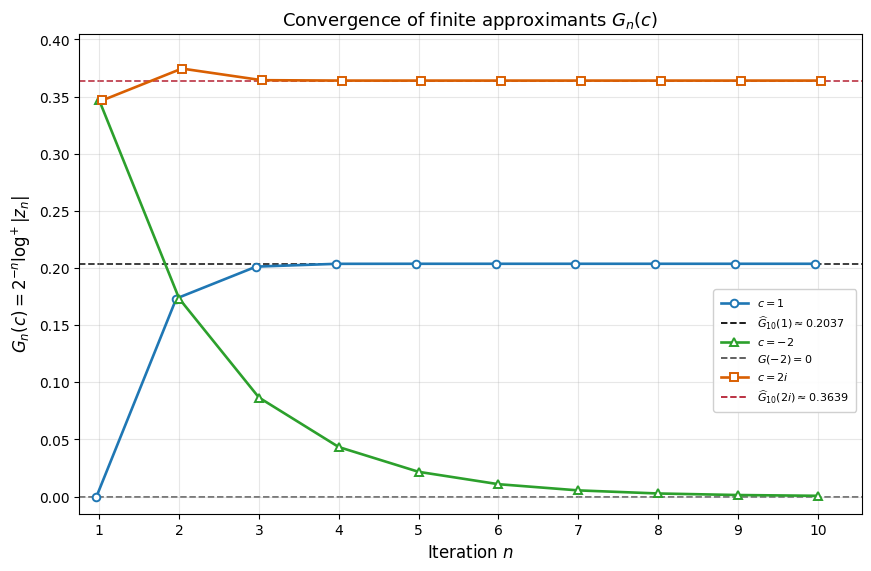

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Iterative convergence of finite approximants G_n(c)
# Quadratic family: z_{n+1} = z_n^2 + c, z_0 = 0
# ============================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


# ------------------------------------------------------------
# Basic functions
# ------------------------------------------------------------

def critical_orbit(c, N):
    """
    Compute z_0, z_1, ..., z_N for

        z_{n+1} = z_n^2 + c,   z_0 = 0.
    """
    z = np.zeros(N + 1, dtype=complex)

    for n in range(N):
        z[n + 1] = z[n]**2 + c

    return z


def log_plus_abs(z):
    """
    Compute log^+|z| = max(log|z|, 0).
    """
    r = np.abs(z)
    out = np.zeros_like(r, dtype=float)

    mask = r > 0
    out[mask] = np.log(r[mask])

    return np.maximum(out, 0.0)


def finite_escape_approximants(c, N):
    """
    Compute

        G_n(c) = 2^{-n} log^+ |z_n|

    for n = 1, ..., N.
    """
    z = critical_orbit(c, N)

    n_values = np.arange(1, N + 1)
    G_values = log_plus_abs(z[1:]) / (2.0 ** n_values)

    return n_values, G_values, z


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

N_plot = 10
N_ref = 10

c_values = [
    1 + 0j,
    -2 + 0j,
    0 + 2j
]

labels = [
    r"$c=1$",
    r"$c=-2$",
    r"$c=2i$"
]

parameter_names = [
    r"1",
    r"-2",
    r"2i"
]

# Colour and marker choices for publication clarity
curve_colors = ["#1f77b4", "#2ca02c", "#d95f02"]   # blue, green, orange
curve_markers = ["o", "^", "s"]

# Dashed reference-line colours
limit_line_colors = ["black", "#4d4d4d", "#b2182b"]  # black, grey, red

# Small horizontal offsets, used only to avoid overlapping markers visually
x_offsets = [-0.035, 0.0, 0.035]


# ------------------------------------------------------------
# Build figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.6, 5.6), constrained_layout=True)

legend_handles = []

for k, (c, label, pname, color, marker) in enumerate(
    zip(c_values, labels, parameter_names, curve_colors, curve_markers)
):
    n_vals, G_vals, _ = finite_escape_approximants(c, N_plot)

    # Finite reference estimate.
    # For c=-2 we know theoretically that G(-2)=0.
    if c == -2 + 0j:
        G_hat = 0.0
        limit_label = r"$G(-2)=0$"
    else:
        _, G_ref_vals, _ = finite_escape_approximants(c, N_ref)
        G_hat = G_ref_vals[-1]
        limit_label = fr"$\widehat{{G}}_{{{N_ref}}}({pname})\approx {G_hat:.4f}$"

    # Shift only the x-coordinates visually, not the mathematical data
    n_plot = n_vals + x_offsets[k]

    # Convergence curve
    ax.plot(
        n_plot,
        G_vals,
        color=color,
        linewidth=1.9,
        marker=marker,
        markersize=5.5,
        markerfacecolor="white",
        markeredgewidth=1.4,
        zorder=3 + k
    )

    # Horizontal limiting/reference line
    ax.axhline(
        G_hat,
        color=limit_line_colors[k],
        linestyle="--",
        linewidth=1.25,
        alpha=0.85,
        zorder=1
    )

    # Legend handle for curve
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            marker=marker,
            markerfacecolor="white",
            markeredgewidth=1.4,
            linewidth=1.9,
            markersize=5.5,
            label=label
        )
    )

    # Legend handle for limiting/reference value
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=limit_line_colors[k],
            linestyle="--",
            linewidth=1.25,
            label=limit_label
        )
    )


# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_title(r"Convergence of finite approximants $G_n(c)$")
ax.set_xlabel(r"Iteration $n$")
ax.set_ylabel(r"$G_n(c)=2^{-n}\log^+|z_n|$")

ax.set_xticks(np.arange(1, N_plot + 1))
ax.set_xlim(0.75, N_plot + 0.55)

# Small negative lower bound so the G(-2)=0 reference line is visible
ax.set_ylim(-0.015, 0.405)

ax.grid(True, alpha=0.30)


ax.legend(
    handles=legend_handles,
    loc="center right",
    bbox_to_anchor=(1.00, 0.34),
    framealpha=0.92,
    fontsize=8.0,
    handlelength=2.5,
    borderpad=0.65,
    labelspacing=0.45
)




# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.savefig(
    "figure_iterative_convergence_Gn_refined.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "figure_iterative_convergence_Gn_refined.pdf",
    bbox_inches="tight"
)

plt.show()


# Iterative Convergence of Finite Escape-Rate Approximants

This section studies the numerical convergence of the finite escape-rate approximants

$$
G_n(c)=\frac{\log^+|z_n|}{2^n},
$$

where the critical orbit is generated by

$$
z_0=0,
\qquad
z_{n+1}=z_n^2+c.
$$

The goal is to compare the behaviour of $G_n(c)$ for three representative parameters:

$$
c=1,
\qquad
c=-2,
\qquad
c=2i.
$$

These parameters illustrate three important cases:

1. $c=1$ is an escaping real parameter.
2. $c=-2$ is a boundary parameter of the Mandelbrot set.
3. $c=2i$ is an escaping complex parameter.

The generated figure shows how the finite approximants $G_n(c)$ evolve as the iteration index $n$ increases.

---

## Mathematical Context

For the quadratic family

$$
f_c(z)=z^2+c,
$$

the critical orbit is

$$
z_n(c)=f_c^{\circ n}(0).
$$

The regularized finite approximant is

$$
G_n(c)=2^{-n}\log^+|z_n|.
$$

Here,

$$
\log^+ r=\max\{\log r,0\}.
$$

For escaping parameters $c\notin\mathcal M$, the approximants converge to the escape-rate function

$$
G(c)=\lim_{n\to\infty}G_n(c).
$$

For bounded or non-escaping parameters $c\in\mathcal M$, the critical orbit remains bounded and

$$
G_n(c)\to 0.
$$

Thus the finite sequence $G_n(c)$ provides a numerical way to distinguish bounded and escaping behaviour.

---
## Core Python Computation

The essential computation is the repeated iteration of the critical orbit and the evaluation of the normalized logarithmic quantity.

```python
import numpy as np

def critical_orbit(c, N):
    z = np.zeros(N + 1, dtype=complex)

    for n in range(N):
        z[n + 1] = z[n]**2 + c

    return z


def log_plus_abs(z):
    r = np.abs(z)
    out = np.zeros_like(r, dtype=float)

    mask = r > 0
    out[mask] = np.log(r[mask])

    return np.maximum(out, 0.0)


def finite_escape_approximants(c, N):
    z = critical_orbit(c, N)

    n_values = np.arange(1, N + 1)
    G_values = log_plus_abs(z[1:]) / (2.0 ** n_values)

    return n_values, G_values, z
```

This code implements the mathematical formula

$$
G_n(c)=\frac{\log^+|z_n|}{2^n}.
$$

---

## Functions Used in the Code

### 1. Critical Orbit Function

```python
critical_orbit(c, N)
```

This function computes

$$
z_0,z_1,\ldots,z_N
$$

using the recurrence

$$
z_{n+1}=z_n^2+c.
$$

It gives the finite critical orbit associated with the parameter $c$.

---

### 2. Positive Logarithm Function

```python
log_plus_abs(z)
```

This function computes

$$
\log^+|z|
=
\max\{\log|z|,0\}.
$$

The positive logarithm is used so that points with $|z|\leq 1$ contribute zero rather than negative logarithmic values.

---

### 3. Finite Approximant Function

```python
finite_escape_approximants(c, N)
```

This function computes the finite sequence

$$
G_1(c),G_2(c),\ldots,G_N(c).
$$

It returns:

1. the iteration indices $n$;
2. the approximants $G_n(c)$;
3. the critical orbit values $z_n$.

---

## Algorithmic Summary

```text
Algorithm: Iterative Convergence of Finite Escape-Rate Approximants

Input:
    parameter list c_1, c_2, c_3
    maximum plotting iteration N_plot
    reference iteration N_ref

Step 1:
    For each parameter c_j:
        set z_0 = 0

Step 2:
    Iterate
        z_{n+1}=z_n^2+c_j

Step 3:
    For each n, compute
        G_n(c_j)=2^{-n} log^+ |z_n|

Step 4:
    If c_j is the boundary parameter c=-2:
        use the theoretical limit G(-2)=0

Step 5:
    If c_j is escaping:
        use G_{N_ref}(c_j) as a finite reference estimate

Step 6:
    Plot G_n(c_j) against n

Step 7:
    Add dashed horizontal reference lines:
        G(-2)=0 for the boundary case
        G_{N_ref}(c_j) for escaping cases

Output:
    A convergence plot comparing the finite approximants for
    c=1, c=-2, and c=2i.
```

---

## Parameter Choices

The code uses

$$
c=1,
\qquad
c=-2,
\qquad
c=2i.
$$

These choices are mathematically useful because they show three distinct behaviours.
---

## Case 1: The Escaping Parameter $c=1$

For

$$
c=1,
$$

the critical orbit begins as follows:

$$
z_0=0,
$$

$$
z_1=1,
$$

$$
z_2=2,
$$

$$
z_3=5,
$$

$$
z_4=26,
$$

$$
z_5=677.
$$

The corresponding finite approximants are

$$
G_1(1)=0,
$$

$$
G_2(1)=\frac{\log 2}{4},
$$

$$
G_3(1)=\frac{\log 5}{8},
$$

$$
G_4(1)=\frac{\log 26}{16},
$$

$$
G_5(1)=\frac{\log 677}{32}.
$$

These values stabilize near a positive number. In the manuscript, this value is approximately

$$
G(1)\approx 0.20368.
$$

Thus $c=1$ illustrates an escaping parameter with positive escape rate.

---

## Case 2: The Boundary Parameter $c=-2$

For

$$
c=-2,
$$

the critical orbit is

$$
z_0=0,
$$

$$
z_1=-2,
$$

$$
z_2=2,
$$

$$
z_3=2,
$$

$$
z_4=2,
$$

and the orbit remains bounded.

Hence

$$
|z_n|=2
\qquad
\text{for all } n\geq 1.
$$

Therefore,

$$
G_n(-2)=\frac{\log 2}{2^n}.
$$

Since

$$
\frac{\log 2}{2^n}\to 0,
$$

we obtain

$$
G(-2)=0.
$$

This is why the code uses the exact reference line

$$
G(-2)=0.
$$

This case illustrates the vanishing of the escape-rate function for a non-escaping boundary parameter.

---

## Case 3: The Escaping Complex Parameter $c=2i$

For

$$
c=2i,
$$

the first few iterates are

$$
z_1=2i,
$$

$$
z_2=-4+2i,
$$

$$
z_3=12-14i,
$$

$$
z_4=-52-334i.
$$

The corresponding magnitudes are

$$
|z_1|=2,
$$

$$
|z_2|=\sqrt{20},
$$

$$
|z_3|=\sqrt{340},
$$

$$
|z_4|=\sqrt{114260}.
$$

Thus

$$
G_1(2i)=\frac{\log 2}{2},
$$

$$
G_2(2i)=\frac{\log\sqrt{20}}{4},
$$

$$
G_3(2i)=\frac{\log\sqrt{340}}{8},
$$

$$
G_4(2i)=\frac{\log\sqrt{114260}}{16}.
$$

These approximants stabilize near a positive value. In the manuscript, this value is approximately

$$
G(2i)\approx 0.3648.
$$

Thus $c=2i$ illustrates an escaping complex parameter with positive escape rate.

These approximants stabilize near a positive value. In the manuscript, this value is approximately

$$
G(2i)\approx 0.3648.
$$

Thus $c=2i$ illustrates an escaping complex parameter with positive escape rate.

---

## Interpretation of the Plot

The generated figure compares the numerical sequences

$$
G_n(1),
\qquad
G_n(-2),
\qquad
G_n(2i).
$$

The plot shows three key behaviours:

1. For $c=1$, the approximants stabilize toward a positive value.
2. For $c=-2$, the approximants decay to zero.
3. For $c=2i$, the approximants stabilize toward another positive value.

This demonstrates that the escape-rate function is parameter-dependent.

In particular,

$$
G(1)\neq G(2i),
$$

and neither value is universally equal to $\log 2$.

---

## Why This Code Is Mathematically Justified

The code is justified by the following mathematical facts.

First, the critical orbit is defined by

$$
z_{n+1}=z_n^2+c.
$$

Second, the finite approximants are

$$
G_n(c)=\frac{\log^+|z_n|}{2^n}.
$$

Third, for escaping parameters,

$$
G_n(c)\to G(c)>0.
$$

Fourth, for bounded or non-escaping parameters,

$$
G_n(c)\to 0.
$$

The plotted curves illustrate these convergence behaviours directly.

---

## Numerical Meaning of the Reference Lines

The dashed horizontal reference lines have different interpretations.

For escaping parameters such as $c=1$ and $c=2i$, the dashed line is the finite reference approximation

$$
\widehat G_{N_{\mathrm{ref}}}(c)=G_{N_{\mathrm{ref}}}(c).
$$

For the boundary parameter $c=-2$, the dashed line is the exact theoretical value

$$
G(-2)=0.
$$

Thus the plot combines numerical finite approximations with one exact theoretical boundary value.

---

## Connection with the Research Manuscript

This code corresponds to the iterative convergence plot of finite approximants in the manuscript.

The manuscript uses this type of computation to show that:

1. escaping parameters produce positive limiting escape rates;
2. non-escaping or boundary parameters produce zero escape rate;
3. the escape-rate function depends on the parameter $c$;
4. the normalized approximants $G_n(c)$ are numerically stable.

Therefore, this code provides a compact numerical validation of the regularized escape-rate framework.

---

## Summary

This computation visualizes the convergence of

$$
G_n(c)=2^{-n}\log^+|z_n|
$$

for selected parameters.

The result shows the fundamental distinction:

$$
c\in\mathcal M
\quad\Longrightarrow\quad
G(c)=0,
$$

whereas for escaping parameters,

$$
c\notin\mathcal M
\quad\Longrightarrow\quad
G(c)>0.
$$

The plotted curves demonstrate that the regularized escape-rate function is finite, parameter-dependent, and numerically computable.

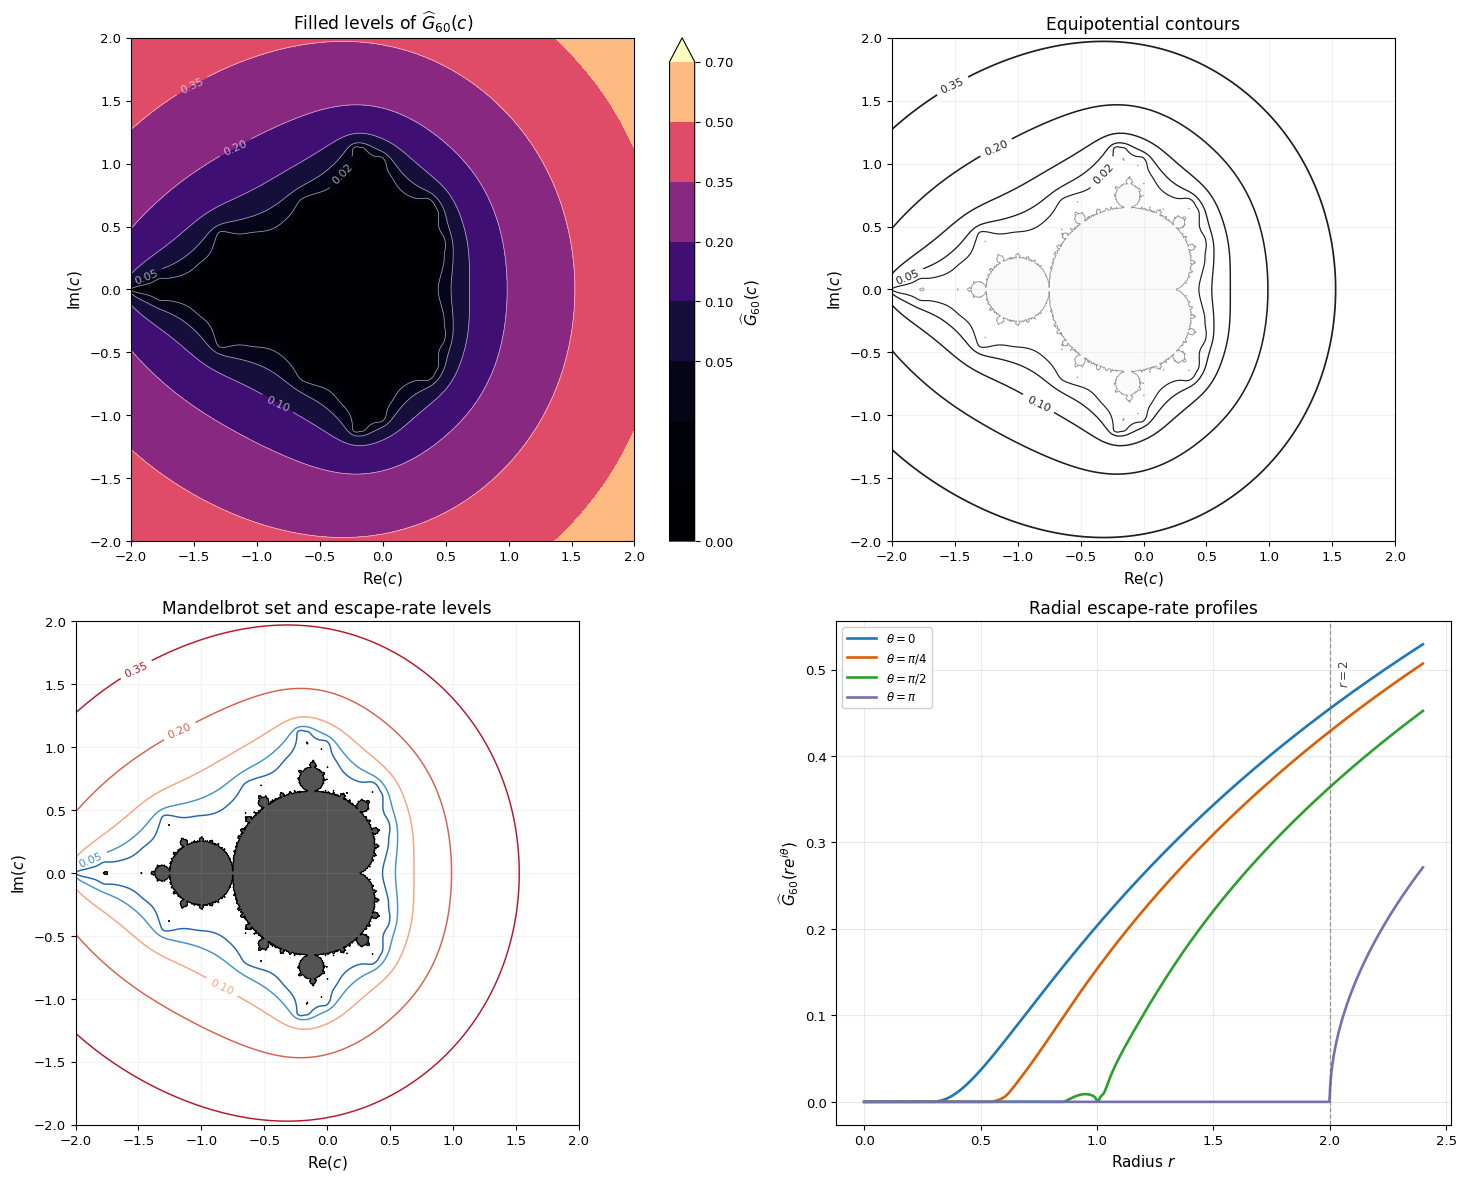

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Four-panel visualization of the regularized escape-rate field
# Quadratic family: z_{n+1} = z_n^2 + c, z_0 = 0
#
# Panels:
# 1. Filled contour plot
# 2. Equipotential contours
# 3. Mandelbrot set with escape-rate levels
# 4. Radial escape-rate profiles
# ============================================================

plt.rcParams.update({
    "font.size": 10.5,
    "axes.titlesize": 12.3,
    "axes.labelsize": 11,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
})


# ------------------------------------------------------------
# Basic helper functions
# ------------------------------------------------------------

def log_plus_abs_array(z):
    """
    Compute log^+|z| = max(log|z|, 0) elementwise.
    """
    r = np.abs(z)
    out = np.zeros_like(r, dtype=float)

    mask = r > 0
    out[mask] = np.log(r[mask])

    return np.maximum(out, 0.0)


def regularized_escape_rate_grid(
    xmin=-2.0,
    xmax=2.0,
    ymin=-2.0,
    ymax=2.0,
    width=750,
    height=750,
    N=60,
    bailout=1e6
):
    """
    Compute a stabilized finite-iteration approximation to the regularized
    escape-rate field.

    The plotted quantity is

        Ghat_N(c) approx 2^{-n} log^+ |z_n|,

    where n is the escape index if the orbit escapes before N,
    and n=N otherwise.

    This is not an escape-time plot. It is synchronized with

        G_n(c)=2^{-n}log^+|z_n|.
    """

    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)

    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y

    Z = np.zeros_like(C, dtype=np.complex128)
    G = np.zeros_like(X, dtype=float)

    active = np.ones_like(X, dtype=bool)

    for n in range(1, N + 1):
        Z[active] = Z[active]**2 + C[active]
        R = np.abs(Z)

        escaped_now = active & (R > bailout)

        # Regularized value at the escape index.
        G[escaped_now] = np.log(R[escaped_now]) / (2.0 ** n)

        active[escaped_now] = False

        # Avoid overflow for already escaped points.
        Z[~active] = 0.0

    # Points not escaped by N are assigned final finite approximation.
    R_final = np.abs(Z)
    G[active] = log_plus_abs_array(R_final[active]) / (2.0 ** N)

    return X, Y, G


def mandelbrot_membership_mask(
    xmin=-2.0,
    xmax=2.0,
    ymin=-2.0,
    ymax=2.0,
    width=750,
    height=750,
    N=300,
    bailout=2.0
):
    """
    Compute an approximate Mandelbrot membership mask.

    A point is marked as bounded up to N if its critical orbit does not cross
    the classical bailout radius |z|=2 by N iterations.
    """

    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)

    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y

    Z = np.zeros_like(C, dtype=np.complex128)
    active = np.ones_like(X, dtype=bool)

    for _ in range(N):
        Z[active] = Z[active]**2 + C[active]

        escaped_now = active & (np.abs(Z) > bailout)

        active[escaped_now] = False
        Z[~active] = 0.0

    return X, Y, active


def regularized_escape_rate_points(c_array, N=60, bailout=1e6):
    """
    Compute Ghat_N(c) for a one-dimensional array of parameters.
    Used for radial profile plots.
    """

    C = np.asarray(c_array, dtype=np.complex128)
    Z = np.zeros_like(C, dtype=np.complex128)

    G = np.zeros(C.shape, dtype=float)
    active = np.ones(C.shape, dtype=bool)

    for n in range(1, N + 1):
        Z[active] = Z[active]**2 + C[active]
        R = np.abs(Z)

        escaped_now = active & (R > bailout)

        G[escaped_now] = np.log(R[escaped_now]) / (2.0 ** n)

        active[escaped_now] = False
        Z[~active] = 0.0

    R_final = np.abs(Z)
    G[active] = log_plus_abs_array(R_final[active]) / (2.0 ** N)

    return G


# ------------------------------------------------------------
# Parameters for computation
# ------------------------------------------------------------

xmin, xmax = -2.0, 2.0
ymin, ymax = -2.0, 2.0

N_field = 60
N_boundary = 300

grid_size = 750
bailout_regularized = 1e6

# Compute regularized escape-rate field
X, Y, G = regularized_escape_rate_grid(
    xmin=xmin,
    xmax=xmax,
    ymin=ymin,
    ymax=ymax,
    width=grid_size,
    height=grid_size,
    N=N_field,
    bailout=bailout_regularized
)

# Compute approximate Mandelbrot membership mask
Xb, Yb, bounded_mask = mandelbrot_membership_mask(
    xmin=xmin,
    xmax=xmax,
    ymin=ymin,
    ymax=ymax,
    width=grid_size,
    height=grid_size,
    N=N_boundary,
    bailout=2.0
)


# ------------------------------------------------------------
# Contour levels
# ------------------------------------------------------------

# Fewer, more interpretable levels.
filled_levels = [0.00, 0.01, 0.02, 0.05, 0.10, 0.20, 0.35, 0.50, 0.70]
line_levels = [0.02, 0.05, 0.10, 0.20, 0.35]

# Clipped field for filled contour visualization only.
# The computed G is not changed; clipping only improves colour contrast.
G_plot = np.clip(G, 0.0, 0.70)


# ============================================================
# Build four-panel figure
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14.5, 11.7),
    constrained_layout=True
)


# ------------------------------------------------------------
# Panel 1: Filled contour plot
# ------------------------------------------------------------

ax = axes[0, 0]

cf = ax.contourf(
    X,
    Y,
    G_plot,
    levels=filled_levels,
    cmap="magma",
    extend="max"
)

cs = ax.contour(
    X,
    Y,
    G,
    levels=line_levels,
    colors="white",
    linewidths=0.55,
    alpha=0.62
)

ax.clabel(
    cs,
    inline=True,
    fontsize=8,
    fmt="%.2f",
    colors="white"
)

cbar = fig.colorbar(
    cf,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    ticks=[0.00, 0.05, 0.10, 0.20, 0.35, 0.50, 0.70]
)

cbar.set_label(fr"$\widehat{{G}}_{{{N_field}}}(c)$")

ax.set_title(fr"Filled levels of $\widehat{{G}}_{{{N_field}}}(c)$")
ax.set_xlabel(r"$\operatorname{Re}(c)$")
ax.set_ylabel(r"$\operatorname{Im}(c)$")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal", adjustable="box")


# ------------------------------------------------------------
# Panel 2: Equipotential contour plot
# ------------------------------------------------------------

ax = axes[0, 1]

# Very light bounded region for orientation
ax.contourf(
    Xb,
    Yb,
    bounded_mask.astype(float),
    levels=[0.5, 1.5],
    colors=["0.88"],
    alpha=0.16
)

# Subtle Mandelbrot boundary
ax.contour(
    Xb,
    Yb,
    bounded_mask.astype(float),
    levels=[0.5],
    colors="0.60",
    linewidths=0.65
)

# Equipotential contours
cs2 = ax.contour(
    X,
    Y,
    G,
    levels=line_levels,
    colors="black",
    linewidths=[0.85, 0.95, 1.05, 1.15, 1.25],
    alpha=0.88
)

ax.clabel(
    cs2,
    inline=True,
    fontsize=8,
    fmt="%.2f"
)

ax.set_title(r"Equipotential contours")
ax.set_xlabel(r"$\operatorname{Re}(c)$")
ax.set_ylabel(r"$\operatorname{Im}(c)$")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.16)


# ------------------------------------------------------------
# Panel 3: Mandelbrot set plus escape-rate level curves
# ------------------------------------------------------------

ax = axes[1, 0]

# Mandelbrot interior approximation, softened
ax.contourf(
    Xb,
    Yb,
    bounded_mask.astype(float),
    levels=[0.5, 1.5],
    colors=["0.18"],
    alpha=0.82
)

# Approximate Mandelbrot boundary
ax.contour(
    Xb,
    Yb,
    bounded_mask.astype(float),
    levels=[0.5],
    colors="black",
    linewidths=0.85
)

# Escape-rate level curves outside
cs3 = ax.contour(
    X,
    Y,
    G,
    levels=line_levels,
    colors=["#2166ac", "#4393c3", "#f4a582", "#d6604d", "#b2182b"],
    linewidths=1.05
)

# Label only less-crowded levels, avoiding the smallest 0.02 near boundary
ax.clabel(
    cs3,
    levels=[0.05, 0.10, 0.20, 0.35],
    inline=True,
    fontsize=8,
    fmt="%.2f"
)

ax.set_title(r"Mandelbrot set and escape-rate levels")
ax.set_xlabel(r"$\operatorname{Re}(c)$")
ax.set_ylabel(r"$\operatorname{Im}(c)$")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.14)


# ------------------------------------------------------------
# Panel 4: Radial / external profile plots
# ------------------------------------------------------------

ax = axes[1, 1]

r_values = np.linspace(0, 2.4, 700)

angles = [
    0,
    np.pi / 4,
    np.pi / 2,
    np.pi
]

angle_labels = [
    r"$\theta=0$",
    r"$\theta=\pi/4$",
    r"$\theta=\pi/2$",
    r"$\theta=\pi$"
]

profile_colors = ["#1f77b4", "#d95f02", "#2ca02c", "#7570b3"]

for theta, label, color in zip(angles, angle_labels, profile_colors):
    c_ray = r_values * np.exp(1j * theta)

    G_profile = regularized_escape_rate_points(
        c_ray,
        N=N_field,
        bailout=bailout_regularized
    )

    ax.plot(
        r_values,
        G_profile,
        linewidth=1.9,
        color=color,
        label=label
    )

# Reference marker for negative real-axis endpoint c=-2
ax.axvline(
    2.0,
    color="0.35",
    linestyle="--",
    linewidth=0.9,
    alpha=0.58
)

# Place r=2 label near the upper part of the dashed line
ylim_top = ax.get_ylim()[1]

ax.text(
    2.035,
    0.92 * ylim_top,
    r"$r=2$",
    rotation=90,
    fontsize=8.5,
    color="0.25",
    va="top"
)

ax.set_title(r"Radial escape-rate profiles")
ax.set_xlabel(r"Radius $r$")
ax.set_ylabel(fr"$\widehat{{G}}_{{{N_field}}}(re^{{i\theta}})$")
ax.grid(True, alpha=0.28)

ax.legend(
    loc="upper left",
    framealpha=0.92,
    fontsize=8.5,
    handlelength=2.5
)


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.savefig(
    "four_panel_escape_rate_representations_publication.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "four_panel_escape_rate_representations_publication.pdf",
    bbox_inches="tight"
)

plt.show()

# Four-Panel Visualization of the Regularized Escape-Rate Field

This section investigates the parameter-space structure of the regularized escape-rate function associated with the quadratic family

$$
f_c(z)=z^2+c,
\qquad
c\in\mathbb C.
$$

Starting from the critical point

$$
z_0=0,
$$

we consider the critical orbit

$$
z_{n+1}=z_n^2+c.
$$

The objective is to visualize how the regularized escape-rate function varies across parameter space and to relate this numerical representation to the theoretical framework developed in the manuscript.

The figure consists of four complementary visualizations:

1. a filled contour representation of the escape-rate field;
2. equipotential contour curves;
3. the Mandelbrot set together with escape-rate level curves;
4. radial escape-rate profiles.

Together, these panels provide a geometric interpretation of the regularized escape-rate function.

---

# Mathematical Background

The finite regularized escape-rate approximant is

$$
G_n(c)
=
\frac{\log^+|z_n|}{2^n},
$$

where

$$
\log^+r
=
\max\{\log r,0\}.
$$

For escaping parameters,

$$
c\notin\mathcal M,
$$

the sequence

$$
G_n(c)
$$

converges to the escape-rate function

$$
G(c)
=
\lim_{n\to\infty}
\frac{\log^+|z_n|}{2^n}.
$$

For bounded parameters,

$$
c\in\mathcal M,
$$

the critical orbit remains bounded and therefore

$$
G(c)=0.
$$

The regularized escape-rate function transforms the rapidly growing orbit magnitude into a finite parameter-space quantity suitable for visualization and numerical study.

---

# Core Computational Idea

The code computes a stabilized finite approximation of the escape-rate field over a large grid of parameter values.

For each parameter

$$
c=x+iy,
$$

the critical orbit

$$
z_{n+1}=z_n^2+c
$$

is iterated starting from

$$
z_0=0.
$$

The numerical approximation recorded at each parameter is

$$
\widehat G_N(c).
$$

If the orbit escapes before iteration $N$, the code stores

$$
\widehat G_N(c)
=
\frac{\log|z_\tau|}{2^\tau},
$$

where $\tau$ is the first escape index.

If the orbit does not escape before iteration $N$, the code stores

$$
\widehat G_N(c)
=
\frac{\log^+|z_N|}{2^N}.
$$

This stabilization avoids numerical overflow while preserving the normalized logarithmic structure of the escape-rate function.

---

# Core Python Computation

The central numerical idea may be summarized as follows:

```python
def regularized_escape_rate_points(c_array, N=60, bailout=1e6):

    C = np.asarray(c_array, dtype=np.complex128)
    Z = np.zeros_like(C, dtype=np.complex128)

    G = np.zeros(C.shape, dtype=float)
    active = np.ones(C.shape, dtype=bool)

    for n in range(1, N + 1):

        Z[active] = Z[active]**2 + C[active]
        R = np.abs(Z)

        escaped_now = active & (R > bailout)

        G[escaped_now] = np.log(R[escaped_now]) / (2.0**n)

        active[escaped_now] = False

    return G
```

This computation performs the following steps:

1. initialize the critical orbit with $z_0=0$;
2. iterate $z_{n+1}=z_n^2+c$;
3. monitor the orbit magnitude $|z_n|$;
4. record the normalized logarithmic quantity;
5. assign a stabilized escape-rate value to each parameter.

The full code extends this idea to an entire parameter-space grid and generates the four-panel visualization.

---

# Functions Used in the Code

## 1. Positive Logarithm Function

```python
log_plus_abs_array(z)
```

This function computes

$$
\log^+|z|
=
\max\{\log|z|,0\}
$$

elementwise over an array.

This prevents negative logarithmic values from appearing when

$$
|z|\leq 1.
$$

---

## 2. Escape-Rate Field Function

```python
regularized_escape_rate_grid(...)
```

This function computes a stabilized finite approximation of

$$
G(c)
$$

over a two-dimensional grid of complex parameters.

The output is a scalar field

$$
\widehat G_N(c)
$$

which approximates the regularized escape-rate function.

---

## 3. Mandelbrot Membership Function

```python
mandelbrot_membership_mask(...)
```

This function computes an approximate membership mask for the Mandelbrot set.

A parameter is treated as bounded if its critical orbit does not cross the classical escape radius

$$
|z|=2
$$

within the prescribed number of iterations.

The output is therefore an approximation of

$$
\mathcal M.
$$

---

## 4. Escape-Rate Profile Function

```python
regularized_escape_rate_points(...)
```

This function evaluates the finite escape-rate approximation along one-dimensional parameter families such as

$$
c=re^{i\theta}.
$$

These evaluations are used for the radial profile plots.

---

# Algorithmic Summary

```text
Algorithm: Four-Panel Escape-Rate Visualization

Input:
    parameter-space domain Omega
    grid resolution
    iteration count N
    bailout radius B

Step 1:
    Generate a parameter grid

        c = x + iy

Step 2:
    For each parameter c:

        initialize z_0 = 0

        iterate

            z_{n+1}=z_n^2+c

Step 3:
    If the orbit escapes:

        assign

            log|z_tau| / 2^tau

Step 4:
    Otherwise assign

            log^+|z_N| / 2^N

Step 5:
    Construct the scalar field

            G_hat_N(c)

Step 6:
    Generate:

        - filled contour plot
        - equipotential contours
        - Mandelbrot set overlay
        - radial profile plots

Output:
    A four-panel visualization of the
    regularized escape-rate field.
```

---

# Interpretation of Panel 1: Filled Escape-Rate Field

The first panel displays a filled contour representation of

$$
\widehat G_N(c).
$$

The colour scale encodes the magnitude of the finite escape-rate approximation.

Dark regions correspond to values near zero and therefore indicate bounded or nearly bounded critical orbits.

Brighter regions correspond to larger escape-rate values and indicate more rapid escape.

The panel provides a global view of the escape-rate landscape.

---

# Interpretation of Panel 2: Equipotential Curves

The second panel displays contour curves corresponding to fixed values of

$$
\widehat G_N(c).
$$

These curves approximate level sets of the escape-rate function:

$$
G(c)=\alpha.
$$

Such curves are analogous to equipotential curves in potential theory.

They provide geometric information about how the escape-rate function varies around the Mandelbrot set.

---

# Interpretation of Panel 3: Mandelbrot Set and Escape-Rate Levels

The third panel combines two different objects:

1. an approximation of the Mandelbrot set;
2. escape-rate level curves.

The shaded region corresponds to parameters whose critical orbit remains bounded within the iteration limit.

The surrounding contour curves represent positive escape-rate values.

This panel illustrates how the escape-rate field organizes itself around the Mandelbrot boundary.

---

# Interpretation of Panel 4: Radial Escape-Rate Profiles

The fourth panel studies the escape-rate approximation along radial parameter families

$$
c=re^{i\theta}.
$$

The code considers several angles:

$$
\theta=0,
\qquad
\theta=\frac{\pi}{4},
\qquad
\theta=\frac{\pi}{2},
\qquad
\theta=\pi.
$$

For each direction, the escape-rate approximation

$$
\widehat G_N(re^{i\theta})
$$

is plotted as a function of the radius $r$.

These profiles reveal how escape behaviour varies with both distance and direction in parameter space.

---

# Why This Visualization Is Mathematically Meaningful

The figure visualizes the regularized escape-rate function

$$
G(c)
=
\lim_{n\to\infty}
\frac{\log^+|z_n|}{2^n}.
$$

The regularization is essential because the raw orbit magnitude

$$
|z_n|
$$

can grow too rapidly for meaningful direct comparison.

The logarithm controls this growth, while the normalization by

$$
2^n
$$

compensates for the degree growth of the quadratic map.

As a result,

$$
G(c)
$$

becomes a finite scalar field defined over parameter space.

This allows the escape dynamics of different parameters to be compared quantitatively.

---

# Connection with the Research Manuscript

This figure provides a numerical realization of the regularized escape-rate framework developed throughout the manuscript.

The four panels reveal:

1. the global escape-rate field;
2. approximate equipotential curves;
3. the relationship between the Mandelbrot set and escape-rate levels;
4. directional escape behaviour along radial parameter families.

Together, these visualizations demonstrate how the regularized quantity

$$
G_n(c)
=
\frac{\log^+|z_n|}{2^n}
$$

leads to a meaningful parameter-space function that can be studied analytically, geometrically, and numerically.

---

# Summary

The regularized escape-rate approximation

$$
\widehat G_N(c)
$$

provides a stable numerical representation of the parameter-space escape dynamics of the quadratic family.

The four-panel figure combines:

- filled escape-rate contours,
- equipotential curves,
- Mandelbrot set geometry,
- radial escape-rate profiles.

These visualizations illustrate how logarithmic regularization transforms explosive orbit growth into a finite parameter-space quantity suitable for theoretical analysis and numerical computation.

# **Quantitative Error Analysis and Numerical Convergence**

The existence of the escape-rate function

$$
G(c)=\lim_{n\to\infty}\frac{\log |z_n|}{2^n},
\qquad z_{n+1}=z_n^2+c,\quad z_0=0,
$$

practical computation necessarily relies on a finite iterate \(n\). It is therefore essential to quantify how accurately the finite approximation

$$
G_n(c):=\frac{\log |z_n|}{2^n}
$$

approximates the limiting value $G(c)$ once the orbit has entered the escaping regime. The aim of this section is twofold. First, we derive a rigorous quantitative error bound showing that $G_n(c)$ converges to $G(c)$ at an exponential rate $O(2^{-n})$. Second, we translate this estimate into explicit stopping criteria and numerical algorithms suitable for stable computation.

> **Lemma**
>Let $c\in\mathbb{C}$, and let $z_{n+1}=z_n^2+c$. Suppose $z_n\neq 0$. Then
>$$
G_{n+1}(c)-G_n(c)
=
\frac{1}{2^{n+1}}
\log\left|1+\frac{c}{z_n^2}\right|.
$$
> is the key identity behind the quantitative theory. It shows that the difference between consecutive approximants is controlled by the perturbation term $c/z_n^2$, which becomes small once the orbit is sufficiently far from the origin.


## **Quantitative $O(2^{-n})$ Convergence**

We now derive an explicit error bound for the finite approximants $G_n(c)$.

>**Theorem (Quantitative $O(2^{-n})$ Convergence Bound):**
Let $c\in\mathbb{C}\setminus\mathcal{M}$, and let $z_{n+1}=z_n^2+c$, $z_0=0$. Assume that for some $n_0\in\mathbb{N}$,
$$
|z_{n_0}|\ge R,
\qquad
R>\max\{2,\sqrt{2|c|}\}.
$$
Then for every $n\ge n_0$,
$$
|G(c)-G_n(c)|
\le
\frac{1}{2^n}
\left[
-\log\left(1-\frac{|c|}{R^2}\right)
\right].
$$
Consequently,
$$
|G(c)-G_n(c)|=O(2^{-n})
\qquad (n\to\infty).
$$

The Theorem provides a rigorous quantitative version of the convergence

$$
G_n(c)\to G(c).
$$

It shows that once the orbit has entered the far-field regime $|z_n|\ge R$, the remaining tail error decays exponentially with respect to the iteration index $n$. This makes the regularized escape-rate function particularly suitable for numerical computation.

In [ ]:

import math
import cmath


# ============================================================
# Quadratic critical orbit: z_{n+1} = z_n^2 + c, z_0 = 0
# ============================================================

def iterate_quadratic(c, n_max):
    """
    Compute the critical orbit
        z_{n+1} = z_n^2 + c,    z_0 = 0.

    Parameters
    ----------
    c : complex
        Parameter in the quadratic map f_c(z)=z^2+c.
    n_max : int
        Maximum number of iterations.

    Returns
    -------
    orbit : list of complex
        List [z_0, z_1, ..., z_n_max].
    """
    if n_max < 0:
        raise ValueError("n_max must be non-negative.")

    z = 0 + 0j
    orbit = [z]

    for _ in range(n_max):
        z = z * z + c
        orbit.append(z)

    return orbit


# ============================================================
# Finite approximant G_n(c)
# ============================================================

def compute_Gn(z, n, use_log_plus=True):
    """
    Compute the finite escape-rate approximant

        G_n(c) = log^+|z_n| / 2^n

    or, after escape,

        G_n(c) = log|z_n| / 2^n.

    Parameters
    ----------
    z : complex
        The iterate z_n.
    n : int
        Iteration index.
    use_log_plus : bool
        If True, use log^+(|z|)=max(log|z|,0).
        If False, use log(|z|), assuming |z|>0.

    Returns
    -------
    float
        Value of G_n(c).
    """
    if n <= 0:
        raise ValueError("G_n is intended for n >= 1.")

    r = abs(z)

    if r == 0:
        if use_log_plus:
            return 0.0
        return float("-inf")

    if use_log_plus:
        return max(math.log(r), 0.0) / (2 ** n)

    return math.log(r) / (2 ** n)


# ============================================================
# Escape-radius admissibility
# ============================================================

def is_admissible_escape_radius(c, R):
    """
    Check the theorem condition

        R > max{2, sqrt(2|c|)}.

    Parameters
    ----------
    c : complex
        Parameter in the quadratic map.
    R : float
        Escape radius.

    Returns
    -------
    bool
        True if R satisfies the theorem condition.
    """
    return R > max(2.0, math.sqrt(2.0 * abs(c)))


def validate_escape_radius(c, R):
    """
    Raise an error if the escape radius does not satisfy

        R > max{2, sqrt(2|c|)}.
    """
    if R <= 0:
        raise ValueError("R must be positive.")

    if not is_admissible_escape_radius(c, R):
        raise ValueError(
            "The corrected theorem requires "
            "R > max{2, sqrt(2|c|)}."
        )


# ============================================================
# Corrected certified error bound
# ============================================================

def certified_error_bound(c, n, R):
    """
    Compute the corrected rigorous error bound

        E_n = (1 / 2^n) * [-log(1 - |c| / R^2)].

    This corresponds to the corrected quantitative convergence theorem.

    Parameters
    ----------
    c : complex
        Parameter in the quadratic map.
    n : int
        Iteration index.
    R : float
        Escape radius satisfying R > max{2, sqrt(2|c|)}.

    Returns
    -------
    float
        Certified error bound.
    """
    if n <= 0:
        raise ValueError("n must be at least 1.")

    validate_escape_radius(c, R)

    ratio = abs(c) / (R ** 2)

    if ratio >= 1:
        raise ValueError("The bound requires |c|/R^2 < 1.")

    return (-math.log(1.0 - ratio)) / (2 ** n)


# ============================================================
# Corrected theoretical stopping index
# ============================================================

def stopping_index(c, epsilon, R):
    """
    Compute a sufficient theoretical stopping index

        n_stop = ceil(
            log_2(
                (1/epsilon) * [-log(1 - |c|/R^2)]
            )
        ).

    Parameters
    ----------
    c : complex
        Parameter in the quadratic map.
    epsilon : float
        Target tolerance.
    R : float
        Escape radius satisfying R > max{2, sqrt(2|c|)}.

    Returns
    -------
    int
        Certified stopping index.
    """
    if epsilon <= 0:
        raise ValueError("epsilon must be positive.")

    validate_escape_radius(c, R)

    constant = -math.log(1.0 - abs(c) / (R ** 2))
    value = constant / epsilon

    # If value <= 1, then n=0 would already satisfy the inequality.
    # Since G_n is used for n>=1, return 1 in practice.
    if value <= 1:
        return 1

    return math.ceil(math.log(value, 2))


# ============================================================
# Tolerance-based computation of G(c)
# ============================================================

def tolerance_based_escape_rate(c, epsilon=1e-8, R=10.0, n_max=100):
    """
    Compute G_n(c) using the corrected rigorous stopping criterion.

    The orbit is iterated until |z_n| >= R. After that, the corrected
    certified error bound

        E_n = 2^{-n}[-log(1 - |c|/R^2)]

    is checked. If E_n <= epsilon, the computation terminates with
    a certified approximation.

    Parameters
    ----------
    c : complex
        Parameter in the quadratic map.
    epsilon : float
        Desired error tolerance.
    R : float
        Escape radius satisfying R > max{2, sqrt(2|c|)}.
    n_max : int
        Maximum iteration count.

    Returns
    -------
    result : dict
        Dictionary containing computed data.
    """
    if n_max <= 0:
        raise ValueError("n_max must be positive.")

    validate_escape_radius(c, R)

    z = 0 + 0j
    escaped = False
    escape_index = None

    theoretical_n_stop = stopping_index(c, epsilon, R)

    for n in range(1, n_max + 1):
        z = z * z + c

        if abs(z) >= R:
            if not escaped:
                escaped = True
                escape_index = n

            Gn = compute_Gn(z, n, use_log_plus=False)
            En = certified_error_bound(c, n, R)

            if En <= epsilon:
                return {
                    "c": c,
                    "escaped": True,
                    "escape_index": escape_index,
                    "n": n,
                    "theoretical_n_stop": theoretical_n_stop,
                    "z_n": z,
                    "abs_z_n": abs(z),
                    "G_n": Gn,
                    "error_bound": En,
                    "epsilon": epsilon,
                    "R": R,
                    "message": "Certified approximation found using the corrected error bound."
                }

    final_Gn = compute_Gn(z, n_max, use_log_plus=True)

    return {
        "c": c,
        "escaped": escaped,
        "escape_index": escape_index,
        "n": n_max,
        "theoretical_n_stop": theoretical_n_stop,
        "z_n": z,
        "abs_z_n": abs(z),
        "G_n": final_Gn,
        "error_bound": certified_error_bound(c, n_max, R) if escaped else None,
        "epsilon": epsilon,
        "R": R,
        "message": "No certified approximation within n_max."
    }


# ============================================================
# Display tables for examples
# ============================================================

def print_orbit_table(c, n_max, R=10.0):
    """
    Print a table of z_n, |z_n|, G_n(c), and the corrected error bound
    after escape has occurred.

    Parameters
    ----------
    c : complex
        Parameter in the quadratic map.
    n_max : int
        Maximum iteration count.
    R : float
        Escape radius.
    """
    validate_escape_radius(c, R)

    orbit = iterate_quadratic(c, n_max)

    print(f"\nParameter c = {c}")
    print(f"Escape radius R = {R}")
    print("-" * 112)
    print(
        f"{'n':>3} "
        f"{'z_n':>30} "
        f"{'|z_n|':>18} "
        f"{'G_n(c)':>18} "
        f"{'E_n corrected':>18} "
        f"{'escaped?':>10}"
    )
    print("-" * 112)

    for n in range(1, len(orbit)):
        z_n = orbit[n]
        abs_z_n = abs(z_n)
        escaped = abs_z_n >= R

        Gn = compute_Gn(z_n, n, use_log_plus=not escaped)

        if escaped:
            En = certified_error_bound(c, n, R)
            En_text = f"{En:.10e}"
        else:
            En_text = "not applied"

        print(
            f"{n:>3} "
            f"{str(z_n):>30} "
            f"{abs_z_n:>18.10f} "
            f"{Gn:>18.10f} "
            f"{En_text:>18} "
            f"{str(escaped):>10}"
        )


# ============================================================
# Validate examples from the manuscript
# ============================================================

def validate_examples():
    """
    Validate the examples discussed in the paper using the corrected
    quantitative convergence bound.
    """
    examples = [
        2 + 0j,
        1 + 0j,
        -2 + 0j,
        2j,
        1.5 + 1.5j
    ]

    epsilon = 1e-8
    R = 10.0
    n_max = 50

    for c in examples:
        print_orbit_table(c, 8, R=R)

        result = tolerance_based_escape_rate(
            c,
            epsilon=epsilon,
            R=R,
            n_max=n_max
        )

        print("\nCorrected certified computation summary:")
        print(f"c                    = {result['c']}")
        print(f"escaped              = {result['escaped']}")
        print(f"escape index         = {result['escape_index']}")
        print(f"returned n           = {result['n']}")
        print(f"theoretical n_stop   = {result['theoretical_n_stop']}")
        print(f"|z_n|                = {result['abs_z_n']}")
        print(f"G_n(c)               = {result['G_n']}")
        print(f"corrected bound E_n  = {result['error_bound']}")
        print(f"epsilon              = {result['epsilon']}")
        print(f"R                    = {result['R']}")
        print(f"message              = {result['message']}")
        print("=" * 112)


# ============================================================
# Example: manual calculation for manuscript values
# ============================================================

def manuscript_error_examples(R=10.0):
    """
    Print the corrected manuscript-level error bounds for the examples
    where R=10 is used.
    """
    cases = [
        ("c = 2, n = 4", 2 + 0j, 4),
        ("c = 1, n = 5", 1 + 0j, 5),
        ("c = 2i, n = 4", 2j, 4),
        ("c = 1.5+1.5i, n = 4", 1.5 + 1.5j, 4),
    ]

    print("\nCorrected manuscript error bounds")
    print("-" * 72)
    print(f"{'case':>22} {'|c|':>12} {'n':>5} {'E_n corrected':>22}")
    print("-" * 72)

    for name, c, n in cases:
        validate_escape_radius(c, R)
        En = certified_error_bound(c, n, R)
        print(f"{name:>22} {abs(c):>12.8f} {n:>5} {En:>22.10e}")


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":
    validate_examples()
    manuscript_error_examples(R=10.0)



Parameter c = (2+0j)
Escape radius R = 10.0
----------------------------------------------------------------------------------------------------------------
  n                            z_n              |z_n|             G_n(c)      E_n corrected   escaped?
----------------------------------------------------------------------------------------------------------------
  1                         (2+0j)       2.0000000000       0.3465735903        not applied      False
  2                         (6+0j)       6.0000000000       0.4479398673        not applied      False
  3                        (38+0j)      38.0000000000       0.4546982700   2.5253384147e-03       True
  4                      (1446+0j)    1446.0000000000       0.4547847752   1.2626692073e-03       True
  5                   (2090918+0j) 2090918.0000000000       0.4547848051   6.3133460367e-04       True
  6             (4371938082726+0j) 4371938082726.0000000000       0.4547848051   3.1566730184e-04       True
  

# Certified Computation of the Regularized Escape-Rate Function

This section implements a certified numerical procedure for approximating the regularized escape-rate function associated with the quadratic family

$$
f_c(z)=z^2+c,
\qquad
c\in\mathbb C.
$$

Starting from the critical point

$$
z_0=0,
$$

the critical orbit is generated by

$$
z_{n+1}=z_n^2+c.
$$

The escape-rate function is defined by

$$
G(c)
=
\lim_{n\to\infty}
\frac{\log^+|z_n|}{2^n}.
$$

The purpose of this code is not only to compute finite approximations of $G(c)$, but also to provide a mathematically rigorous error estimate and a certified stopping criterion.

Consequently, every computed approximation is accompanied by a provable upper bound on the approximation error.

---

## Mathematical Framework

The finite escape-rate approximants are

$$
G_n(c)
=
\frac{\log^+|z_n|}{2^n}.
$$

For escaping parameters,

$$
c\notin\mathcal M,
$$

the sequence $G_n(c)$ converges to

$$
G(c).
$$

The quantitative convergence theorem provides the rigorous estimate

$$
|G(c)-G_n(c)|
\le
\frac{1}{2^n}
\left[
-\log
\left(
1-\frac{|c|}{R^2}
\right)
\right],
$$

provided that

$$
R>\max\left\{2,\sqrt{2|c|}\right\}
$$

and

$$
|z_n|\ge R.
$$

Define

$$
E_n
=
\frac{1}{2^n}
\left[
-\log
\left(
1-\frac{|c|}{R^2}
\right)
\right].
$$

Then

$$
|G(c)-G_n(c)|
\le
E_n.
$$

Therefore, $E_n$ serves as a certified upper bound for the approximation error.

---

## Core Python Computation

The fundamental computation begins with the critical orbit.

```python
import math

def iterate_quadratic(c, n_max):

    z = 0 + 0j
    orbit = [z]

    for _ in range(n_max):
        z = z*z + c
        orbit.append(z)

   return orbit
```

This function computes

$$
z_0,z_1,\ldots,z_n
$$

using the recurrence

$$
z_{n+1}=z_n^2+c.
$$

In mathematical notation,

$$
z_n(c)=f_c^{\circ n}(0).
$$

---

## Finite Escape-Rate Approximants

The function

```python
compute_Gn(...)
```

implements

$$
G_n(c)
=
\frac{\log^+|z_n|}{2^n}.
$$

Once the orbit has escaped beyond the chosen escape radius $R$, one may use

$$
G_n(c)
=
\frac{\log|z_n|}{2^n},
$$

because

$$
\log^+|z_n|
=
\log|z_n|
$$

whenever

$$
|z_n|>1.
$$

Thus, after escape has occurred, the finite approximants are computed using the ordinary logarithm while preserving the same normalization by $2^n$.

---

## Escape Radius Condition

The convergence theorem requires the admissibility condition

$$
R>\max\left\{2,\sqrt{2|c|}\right\}.
$$

The functions

```python
is_admissible_escape_radius(...)
```

and

```python
validate_escape_radius(...)
```

verify this condition before any certified computation is performed.

This guarantees that the hypotheses of the convergence theorem are satisfied and that the subsequent error estimates are mathematically valid.

---

## Certified Error Bound

The function

```python
certified_error_bound(...)
```

computes

$$
E_n
=
\frac{1}{2^n}
\left[
-\log
\left(
1-\frac{|c|}{R^2}
\right)
\right].
$$

The quantity $E_n$ provides a rigorous upper bound for the approximation error. More precisely,

$$
|G(c)-G_n(c)|
\le
E_n.
$$

Thus, the finite approximant $G_n(c)$ differs from the exact escape-rate value $G(c)$ by at most $E_n$.

As the iteration index $n$ increases,

$$
E_n
=
O(2^{-n}),
$$

and therefore the approximation error decreases exponentially fast.

Consequently, once the orbit has entered the escaping regime and the hypotheses of the convergence theorem are satisfied, the finite approximants $G_n(c)$ converge rapidly to the escape-rate function

$$
G(c).
$$

---

## Certified Stopping Criterion

Let

$$
\varepsilon>0
$$

be a prescribed error tolerance.

Since

$$
|G(c)-G_n(c)|
\le
\frac{1}{2^n}
\left[
-\log
\left(
1-\frac{|c|}{R^2}
\right)
\right],
$$

it is sufficient to choose $n$ such that

$$
\frac{1}{2^n}
\left[
-\log
\left(
1-\frac{|c|}{R^2}
\right)
\right]
\le
\varepsilon.
$$

Solving this inequality for $n$ yields the theoretical stopping index

$$
n_{\mathrm{stop}}
=
\left\lceil
\log_2
\left(
\frac{
-\log\!\left(
1-\frac{|c|}{R^2}
\right)
}
{\varepsilon}
\right)
\right\rceil.
$$

Therefore, any iteration index satisfying

$$
n\ge n_{\mathrm{stop}}
$$

guarantees that the approximation error is no larger than the prescribed tolerance $\varepsilon$.

The function

```python
stopping_index(...)
```

implements this formula directly and provides a rigorous estimate of the number of iterations required to achieve a certified approximation of the escape-rate function.



---

## Certified Stopping Criterion

Let

$$
\varepsilon>0
$$

be a prescribed error tolerance.

Since the certified error bound satisfies

$$
|G(c)-G_n(c)|
\le
\frac{1}{2^n}
\left[
-\log\left(
1-\frac{|c|}{R^2}
\right)
\right],
$$

it is sufficient to choose $n$ so that

$$
\frac{1}{2^n}
\left[
-\log\left(
1-\frac{|c|}{R^2}
\right)
\right]
\le
\varepsilon.
$$

Solving this inequality for $n$ yields the theoretical stopping index

$$
n_{\mathrm{stop}}
=
\left\lceil
\log_2
\left(
\frac{
-\log\left(
1-\frac{|c|}{R^2}
\right)
}
{\varepsilon}
\right)
\right\rceil.
$$

Therefore, any iteration index

$$
n\ge n_{\mathrm{stop}}
$$

guarantees that the approximation error does not exceed the prescribed tolerance $\varepsilon$.

The function

```python
stopping_index(...)
```

computes this quantity directly. Therefore, the theorem provides an explicit answer to the question:

> How many iterations are required to guarantee a prescribed accuracy?

---

## Tolerance-Based Approximation Algorithm

The function

```python
tolerance_based_escape_rate(...)
```

implements the complete certified computation.

```text
Algorithm: Certified Approximation of G(c)

Input:
    parameter c
    tolerance epsilon
    escape radius R

Step 1:
    Set z_0 = 0.

Step 2:
    Iterate

        z_{n+1}=z_n^2+c.

Step 3:
    Wait until

        |z_n| >= R.

Step 4:
    Compute

        G_n(c)

    and

        E_n.

Step 5:
    If

        E_n <= epsilon,

    terminate and return the approximation.

Output:
    Certified approximation G_n(c)
    together with the rigorous error bound E_n.
```

---

## Numerical Interpretation

The algorithm returns the following quantities.

| Quantity | Interpretation |
|----------|---------------|
| `escape_index` | First iteration satisfying $|z_n|\ge R$ |
| `G_n` | Numerical approximation of $G(c)$ |
| `error_bound` | Certified upper bound for the approximation error |
| `n` | Final iteration used |
| `theoretical_n_stop` | Predicted stopping index |
| `escaped` | Indicates whether escape occurred |

The approximation is therefore accompanied by a mathematically rigorous guarantee rather than a purely empirical estimate.

---

## Connection with the Research Manuscript

This code provides a computational realization of the main quantitative convergence theorem developed in the manuscript.

Specifically, it implements:

1. the critical orbit;
2. the finite approximants $G_n(c)$;
3. the admissible escape-radius condition;
4. the rigorous error bound;
5. the certified stopping criterion;
6. tolerance-controlled approximation of $G(c)$.

Unlike the visualization codes, which illustrate the geometric consequences of the theory, this implementation directly realizes the theorem itself and therefore forms the computational foundation of the manuscript.

---

## Research Significance

Among all computational components developed in the manuscript, this implementation is the most directly tied to the mathematical theorem.

The visualization codes show the geometry of the escape-rate function, whereas this algorithm provides a certified numerical procedure for computing

$$
G(c).
$$

It therefore acts as the computational realization of the quantitative convergence theory and establishes a rigorous bridge between the abstract mathematics and numerical computation.

## **A Simplified Bound**

A simplified estimate can be obtained by replacing the logarithmic constant with an elementary upper bound. Since $0\le \frac{|c|}{R^2}<\frac{1}{2}$
under the hypothesis $R>\sqrt{2|c|}$, we may apply the standard inequality

$$-\log(1-x)\le 2x \qquad (0\le x<1/2).$$

This yields a weaker but more transparent error estimate.

## **Simplified Error Estimate**

$$|G(c)-G_n(c)|\le \frac{2|c|}{2^nR^2}$$

## **Stopping Criterion for Prescribed Accuracy**

The error estimate can be inverted to obtain an explicit stopping criterion. This gives a practical way to decide how many iterations are sufficient to approximate $G(c)$ within a prescribed tolerance.

Let $c\in\mathbb{C}\setminus\mathcal{M}$, and suppose that for some iterate $n_0\in\mathbb{N}$ one has

$$
|z_{n_0}|\ge R,
\qquad
R>\max\{2,\sqrt{2|c|}\}.
$$

Fix a tolerance $\varepsilon>0$. If $n\ge n_0$ satisfies

$$\frac{1}{2^n} \left[-\log\left(1-\frac{|c|}{R^2}\right) \right] \le
\varepsilon, $$

then

$$|G(c)-G_n(c)|\le \varepsilon.$$

Equivalently, it is sufficient to choose $n$ so that

$$
2^n
\ge
\frac{1}{\varepsilon}
\left[
-\log\left(1-\frac{|c|}{R^2}\right)
\right].
$$

Thus one may take

$$
n_{\mathrm{stop}}
=
\left\lceil
\log_2\left(
\frac{1}{\varepsilon}
\left[
-\log\left(1-\frac{|c|}{R^2}\right)
\right]
\right)
\right\rceil.
$$

> **Significance base-$2$ Logarithm:** The appearance of the base-$2$ logarithm is a direct consequence of the quadratic nature of the iteration
$$
z_{n+1}=z_n^2+c.
$$
Indeed, once the orbit has entered the escaping regime, the dominant asymptotic behavior is governed by repeated squaring, so that the natural scaling factor after $n$ steps is $2^n$. For this reason, both the regularized approximants
$$
G_n(c)=\frac{\log|z_n|}{2^n}
$$
and the error bound
$$
|G(c)-G_n(c)|\le \frac{1}{2^n}\log\!\left(1+\frac{|c|}{R^2}\right)
$$
are expressed in terms of powers of $2$. Consequently, when one inverts the inequality to solve for the iteration index $n$, the appropriate inverse function is the logarithm to base $2$:
$$
n\ge \log_2\!\left(\frac{1}{\varepsilon}\log\!\left(1+\frac{|c|}{R^2}\right)\right).
$$

Thus the base-$2$ logarithm is not merely a computational convenience; it reflects the intrinsic doubling mechanism in the logarithmic growth of the quadratic map. More generally, for a polynomial of degree $d$, the corresponding normalization would involve $d^n$, and the analogous stopping criterion would naturally introduce the base-$d$ logarithm.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import mpmath as mp

# ============================================================
# Output folder
# ============================================================

output_dir = Path(".")
output_dir.mkdir(exist_ok=True)

# ============================================================
# Global publication-style plotting settings
# ============================================================

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.28,
    "grid.linestyle": "-",
    "lines.linewidth": 1.9,
    "lines.markersize": 6,
})

# ============================================================
# High-precision pointwise computation
# ============================================================

def finite_escape_approximants_mp(c, N, dps=150):
    """
    Compute G_n(c)=log^+|z_n|/2^n using high-precision arithmetic.

    This avoids overflow for escaping parameters such as c=2.
    Returns both integer n-values and high-precision G_n-values.
    """
    mp.mp.dps = dps

    c_mp = mp.mpc(c.real, c.imag)
    z = mp.mpc(0, 0)

    n_values = np.arange(1, N + 1)
    G_values_mp = []

    for n in n_values:
        z = z*z + c_mp
        modulus = abs(z)

        if modulus > 1:
            log_plus = mp.log(modulus)
        else:
            log_plus = mp.mpf("0")

        G_n = log_plus / (mp.mpf(2) ** n)
        G_values_mp.append(G_n)

    return n_values, G_values_mp


def first_escape_index(c, R, Nmax=100):
    """
    Return the first n such that |z_n| >= R.
    """
    z = 0 + 0j

    for n in range(1, Nmax + 1):
        z = z*z + c
        if abs(z) >= R:
            return n, z

    return None, z


def certified_error_bound(c, R, n_values):
    """
    Certified error bound from Theorem:
        E_n = 2^{-n}[-log(1 - |c|/R^2)].

    The theorem assumes:
        R > max{2, sqrt(2|c|)}.
    """
    abs_c = abs(c)

    if R <= max(2.0, np.sqrt(2.0 * abs_c)):
        raise ValueError("The theorem requires R > max{2, sqrt(2|c|)}.")

    constant = -np.log(1.0 - abs_c / (R**2))
    return constant / (2.0 ** np.array(n_values, dtype=float))


def save_figure(base_name):
    """
    Save current Matplotlib figure as both PNG and PDF.
    """
    plt.savefig(output_dir / f"{base_name}.png", dpi=300, bbox_inches="tight")
    plt.savefig(output_dir / f"{base_name}.pdf", bbox_inches="tight")
    plt.close()


# ============================================================
# Figure 7: Certified bound versus observed stabilization
# ============================================================

def plot_certified_error_bound():
    """
    Publication-ready Figure 7.

    The certified bound is plotted only for n >= n0, where |z_n0| >= R.
    The observed stabilization error is shown only above a visual floor to avoid
    an excessively large vertical range caused by high-precision convergence.
    """
    c = 2 + 0j
    R = 10.0

    N_plot = 14
    N_ref = 45
    dps = 180

    n0, z_n0 = first_escape_index(c, R)

    if n0 is None:
        raise RuntimeError("The orbit did not cross the chosen escape radius.")

    n_values_ref, G_values_mp = finite_escape_approximants_mp(c, N_ref, dps=dps)

    G_reference = G_values_mp[-1]

    n_values = n_values_ref[:N_plot]
    G_values_plot_mp = G_values_mp[:N_plot]

    certified_mask = n_values >= n0
    n_cert = n_values[certified_mask]

    G_cert_mp = [G_values_plot_mp[i - 1] for i in n_cert]

    observed_error = np.array(
        [float(abs(G_n - G_reference)) for G_n in G_cert_mp],
        dtype=float
    )

    E_values = certified_error_bound(c, R, n_cert)

    # ========================================================
    # Sanity checks for mathematical consistency
    # For c=2 and R=10:
    # z_1=2, z_2=6, z_3=38, so n0=3.
    # E_3 = [-log(1-2/100)] / 2^3 = [-log(0.98)] / 8.
    # ========================================================

    print("n0 =", n0)
    print("First certified bound E_n0 =", E_values[0])
    print("Expected E_3 for c=2, R=10 =", -np.log(0.98) / 8)

    # Avoid plotting extremely tiny observed errors that dominate the y-axis
    visual_floor = 1e-12
    visible_obs = observed_error >= visual_floor

    fig, ax = plt.subplots(figsize=(8.2, 5.6))

    ax.semilogy(
        n_cert,
        E_values,
        color="#1f77b4",
        marker="o",
        linewidth=1.9,
        label=r"Certified bound $E_n$"
    )

    ax.semilogy(
        n_cert[visible_obs],
        observed_error[visible_obs],
        color="#d62728",
        marker="s",
        linestyle="--",
        linewidth=1.9,
        label=r"Observed error above $10^{-12}$"
    )

    ax.axvline(
        n0,
        color="0.35",
        linestyle=":",
        linewidth=1.6,
        label=rf"First certified index $n_0={n0}$"
    )

    ax.set_xlabel(r"Iteration index $n$")
    ax.set_ylabel(r"Error scale")
    ax.set_title(r"Certified error bound versus observed stabilization for $c=2$, $R=10$")

    ax.set_xlim(n0 - 0.5, N_plot + 0.5)
    ax.set_ylim(visual_floor, 5e-3)

    ax.legend(
        loc="upper right",
        frameon=True
    )

    ax.grid(True, which="both", alpha=0.28)

    plt.tight_layout()
    save_figure("figure_error_bound_refined")


# ============================================================
# Figure 8: Tolerance-based stopping criterion
# ============================================================

def plot_certified_stopping_criterion():
    """
    Publication-ready Figure 8.

    This figure visualizes Corollary: stop when E_n <= epsilon.
    Different colors are used from Figure 7 for visual distinction.
    """
    c = 2 + 0j
    R = 10.0
    epsilon = 1e-3
    N = 16

    n0, z_n0 = first_escape_index(c, R)

    if n0 is None:
        raise RuntimeError("The orbit did not cross the chosen escape radius.")

    n_values = np.arange(n0, N + 1)
    E_values = certified_error_bound(c, R, n_values)

    valid_indices = np.where(E_values <= epsilon)[0]

    if len(valid_indices) > 0:
        n_stop = n_values[valid_indices[0]]
    else:
        n_stop = None

    fig, ax = plt.subplots(figsize=(8.2, 5.6))

    ax.semilogy(
        n_values,
        E_values,
        color="#006d5b",
        marker="o",
        linewidth=1.9,
        label=r"Certified bound $E_n$"
    )

    ax.axhline(
        epsilon,
        color="#7b3294",
        linestyle="--",
        linewidth=1.7,
        label=rf"Tolerance $\varepsilon=10^{{-3}}$"
    )

    ax.axvline(
        n0,
        color="0.35",
        linestyle=":",
        linewidth=1.6,
        label=rf"First certified index $n_0={n0}$"
    )

    if n_stop is not None:
        ax.axvline(
            n_stop,
            color="#e66101",
            linestyle="-.",
            linewidth=1.8,
            label=rf"Stopping index $n_{{\mathrm{{stop}}}}={n_stop}$"
        )

    ax.set_xlabel(r"Iteration index $n$")
    ax.set_ylabel(r"Certified error bound $E_n$")
    ax.set_title(r"Certified stopping criterion for $c=2$, $R=10$")

    ax.set_xlim(n0 - 0.5, N + 0.5)

    ax.legend(
        loc="center right",
        frameon=True
    )

    ax.grid(True, which="both", alpha=0.28)

    plt.tight_layout()
    save_figure("figure_stopping_criterion_refined")

    return n_stop


# ============================================================
# Run only Figure 7 and Figure 8
# ============================================================

if __name__ == "__main__":
    plot_certified_error_bound()
    n_stop = plot_certified_stopping_criterion()

    print("Publication-ready figures generated successfully:")
    print(" - figure_error_bound_refined.png")
    print(" - figure_error_bound_refined.pdf")
    print(" - figure_stopping_criterion_refined.png")
    print(" - figure_stopping_criterion_refined.pdf")
    print(f"Certified stopping index: n_stop = {n_stop}")

n0 = 3
First certified bound E_n0 = 0.0025253384146899332
Expected E_3 for c=2, R=10 = 0.0025253384146899332
Publication-ready figures generated successfully:
 - figure_error_bound_refined.png
 - figure_error_bound_refined.pdf
 - figure_stopping_criterion_refined.png
 - figure_stopping_criterion_refined.pdf
Certified stopping index: n_stop = 5


# Certified Error Bounds and Stopping Criteria

This section develops the computational implementation of the quantitative convergence theory for the regularized escape-rate function of the quadratic family

$$
f_c(z)=z^2+c,
\qquad
c\in\mathbb C.
$$

Starting from the critical point

$$
z_0=0,
$$

the critical orbit is generated by

$$
z_{n+1}=z_n^2+c.
$$

The goal of the present computation is not merely to approximate the escape-rate function

$$
G(c),
$$

but to provide rigorous quantitative control over the approximation error and to construct a practical stopping criterion based on the convergence theorem.

The code therefore bridges three perspectives:

1. the mathematical theory of escape rates;
2. the numerical approximation of finite escape-rate values;
3. the algorithmic implementation of certified error control.

---

# Mathematical Background

The finite escape-rate approximants are defined by

$$
G_n(c)
=
\frac{\log^+|z_n|}{2^n}.
$$

For escaping parameters, the sequence

$$
G_n(c)
$$

converges to

$$
G(c)
=
\lim_{n\to\infty}
G_n(c).
$$

The quantitative convergence theorem gives the rigorous estimate

$$
|G(c)-G_n(c)|
\le
E_n,
$$

where

$$
E_n
=
\frac{1}{2^n}
\left[
-\log
\left(
1-\frac{|c|}{R^2}
\right)
\right].
$$

The theorem assumes that

$$
R>\max\left\{
2,\sqrt{2|c|}
\right\}
$$

and

$$
|z_n|\ge R.
$$

The quantity

$$
E_n
$$

is a certified error bound: it provides a mathematically rigorous upper estimate for the approximation error.

Consequently,

$$
G_n(c)
$$

is guaranteed to lie within distance

$$
E_n
$$

of the true escape-rate value.

---

# High-Precision Numerical Computation

The code computes finite approximants using arbitrary-precision arithmetic through the library `mpmath`.

The function

```python
finite_escape_approximants_mp(...)
```

evaluates

$$
G_n(c)
=
\frac{\log^+|z_n|}{2^n}
$$

using high-precision arithmetic.

This is important because escaping parameters such as

$$
c=2
$$

produce orbit values whose magnitudes grow extremely rapidly.

Standard floating-point arithmetic may overflow when evaluating such orbits.

The use of arbitrary precision allows the finite approximants to be computed reliably even when

$$
|z_n|
$$

becomes extremely large.

---

# Detection of the Escape Radius

The function

```python
first_escape_index(...)
```

determines the first iteration index

$$
n_0
$$

such that

$$
|z_{n_0}|
\ge
R.
$$

This index plays a special role in the convergence theorem.

The certified error bound becomes valid only after the orbit has entered the escape region

$$
|z_n|
\ge
R.
$$

Thus

$$
n_0
$$

represents the first iteration at which rigorous error control becomes available.

For the parameter

$$
c=2
$$

and escape radius

$$
R=10,
$$

the orbit is

$$
0
\rightarrow
2
\rightarrow
6
\rightarrow
38
\rightarrow
\cdots
$$

and therefore

$$
n_0=3.
$$

---

# Certified Error Bound

The function

```python
certified_error_bound(...)
```

implements the theoretical quantity

$$
E_n
=
\frac{1}{2^n}
\left[
-\log
\left(
1-\frac{|c|}{R^2}
\right)
\right].
$$

For

$$
c=2,
\qquad
R=10,
$$

the constant appearing in the estimate is

$$
-\log
\left(
1-\frac{2}{100}
\right)
=
-\log(0.98).
$$

Consequently,

$$
E_n
=
\frac{-\log(0.98)}{2^n}.
$$

In particular,

$$
E_3
=
\frac{-\log(0.98)}{8}
\approx
2.5254\times10^{-3}.
$$

This value is printed by the code as a consistency check against the theoretical formula.

---

# Figure 7: Certified Bound versus Observed Stabilization

The first figure compares two quantities.

The blue curve represents the theoretical estimate

$$
E_n.
$$

The red curve represents the observed stabilization error

$$
|G_n(c)-G_{\mathrm{ref}}|,
$$

where

$$
G_{\mathrm{ref}}
=
G_{45}(c)
$$

is used as a highly accurate reference value.

The purpose of the figure is to verify that

$$
|G_n(c)-G_{\mathrm{ref}}|
\le
E_n.
$$

The observed numerical error should remain below the certified theoretical bound.

This demonstrates that the quantitative convergence theorem correctly predicts the behaviour of the finite approximants.

The vertical line at

$$
n_0
$$

indicates the first iteration at which the orbit satisfies

$$
|z_n|\ge R,
$$

and therefore the first iteration where the theorem becomes applicable.

---

# Figure 8: Certified Stopping Criterion

The second figure visualizes the practical stopping rule implied by the convergence theorem.

Suppose that a user specifies a target tolerance

$$
\varepsilon.
$$

The algorithm terminates once

$$
E_n
\le
\varepsilon.
$$

For the example

$$
\varepsilon
=
10^{-3},
$$

the code compares the decreasing sequence

$$
E_n
$$

with the horizontal threshold

$$
10^{-3}.
$$

The first index satisfying

$$
E_n
\le
10^{-3}
$$

is denoted by

$$
n_{\mathrm{stop}}.
$$

This index provides a rigorous stopping criterion because the theorem guarantees

$$
|G(c)-G_n(c)|
\le
\varepsilon.
$$

Hence the computation can terminate with a certified level of accuracy.

---

# Algorithmic Summary

```text
Algorithm: Certified Approximation of the Escape-Rate Function

Input:
    parameter c
    escape radius R
    tolerance epsilon

Step 1:
    Set z_0 = 0.

Step 2:
    Iterate

        z_{n+1}=z_n^2+c.

Step 3:
    Detect the first escape index n_0 satisfying

        |z_n| >= R.

Step 4:
    Compute

        G_n(c)

    and

        E_n.

Step 5:
    Compare E_n with the user-prescribed tolerance epsilon.

Step 6:
    If

        E_n <= epsilon,

    terminate the computation.

Output:
    Certified approximation G_n(c),
    certified error bound E_n,
    stopping index n_stop.
```

---

# Numerical Interpretation

The outputs produced by the code have the following meanings.

| Quantity | Interpretation |
|----------|----------|
| $n_0$ | First iteration satisfying $|z_n|\ge R$ |
| $G_n(c)$ | Finite escape-rate approximation |
| $G_{\mathrm{ref}}$ | High-precision reference approximation |
| $|G_n-G_{\mathrm{ref}}|$ | Observed stabilization error |
| $E_n$ | Certified theoretical error bound |
| $n_{\mathrm{stop}}$ | First iteration satisfying the tolerance requirement |

The comparison between observed stabilization and certified error bounds provides numerical validation of the convergence theorem, while the stopping index converts the theoretical estimate into a practical computational procedure.

---

# Connection with the Research Manuscript

This code implements the quantitative convergence theory developed in the manuscript.

More specifically, it provides:

1. high-precision computation of finite approximants;
2. identification of the escape index;
3. evaluation of the rigorous error bound;
4. comparison between observed and certified errors;
5. implementation of a certified stopping rule.

Unlike the geometric visualization codes, the present computation directly realizes the core convergence theorem and therefore constitutes the main numerical validation of the theoretical results.

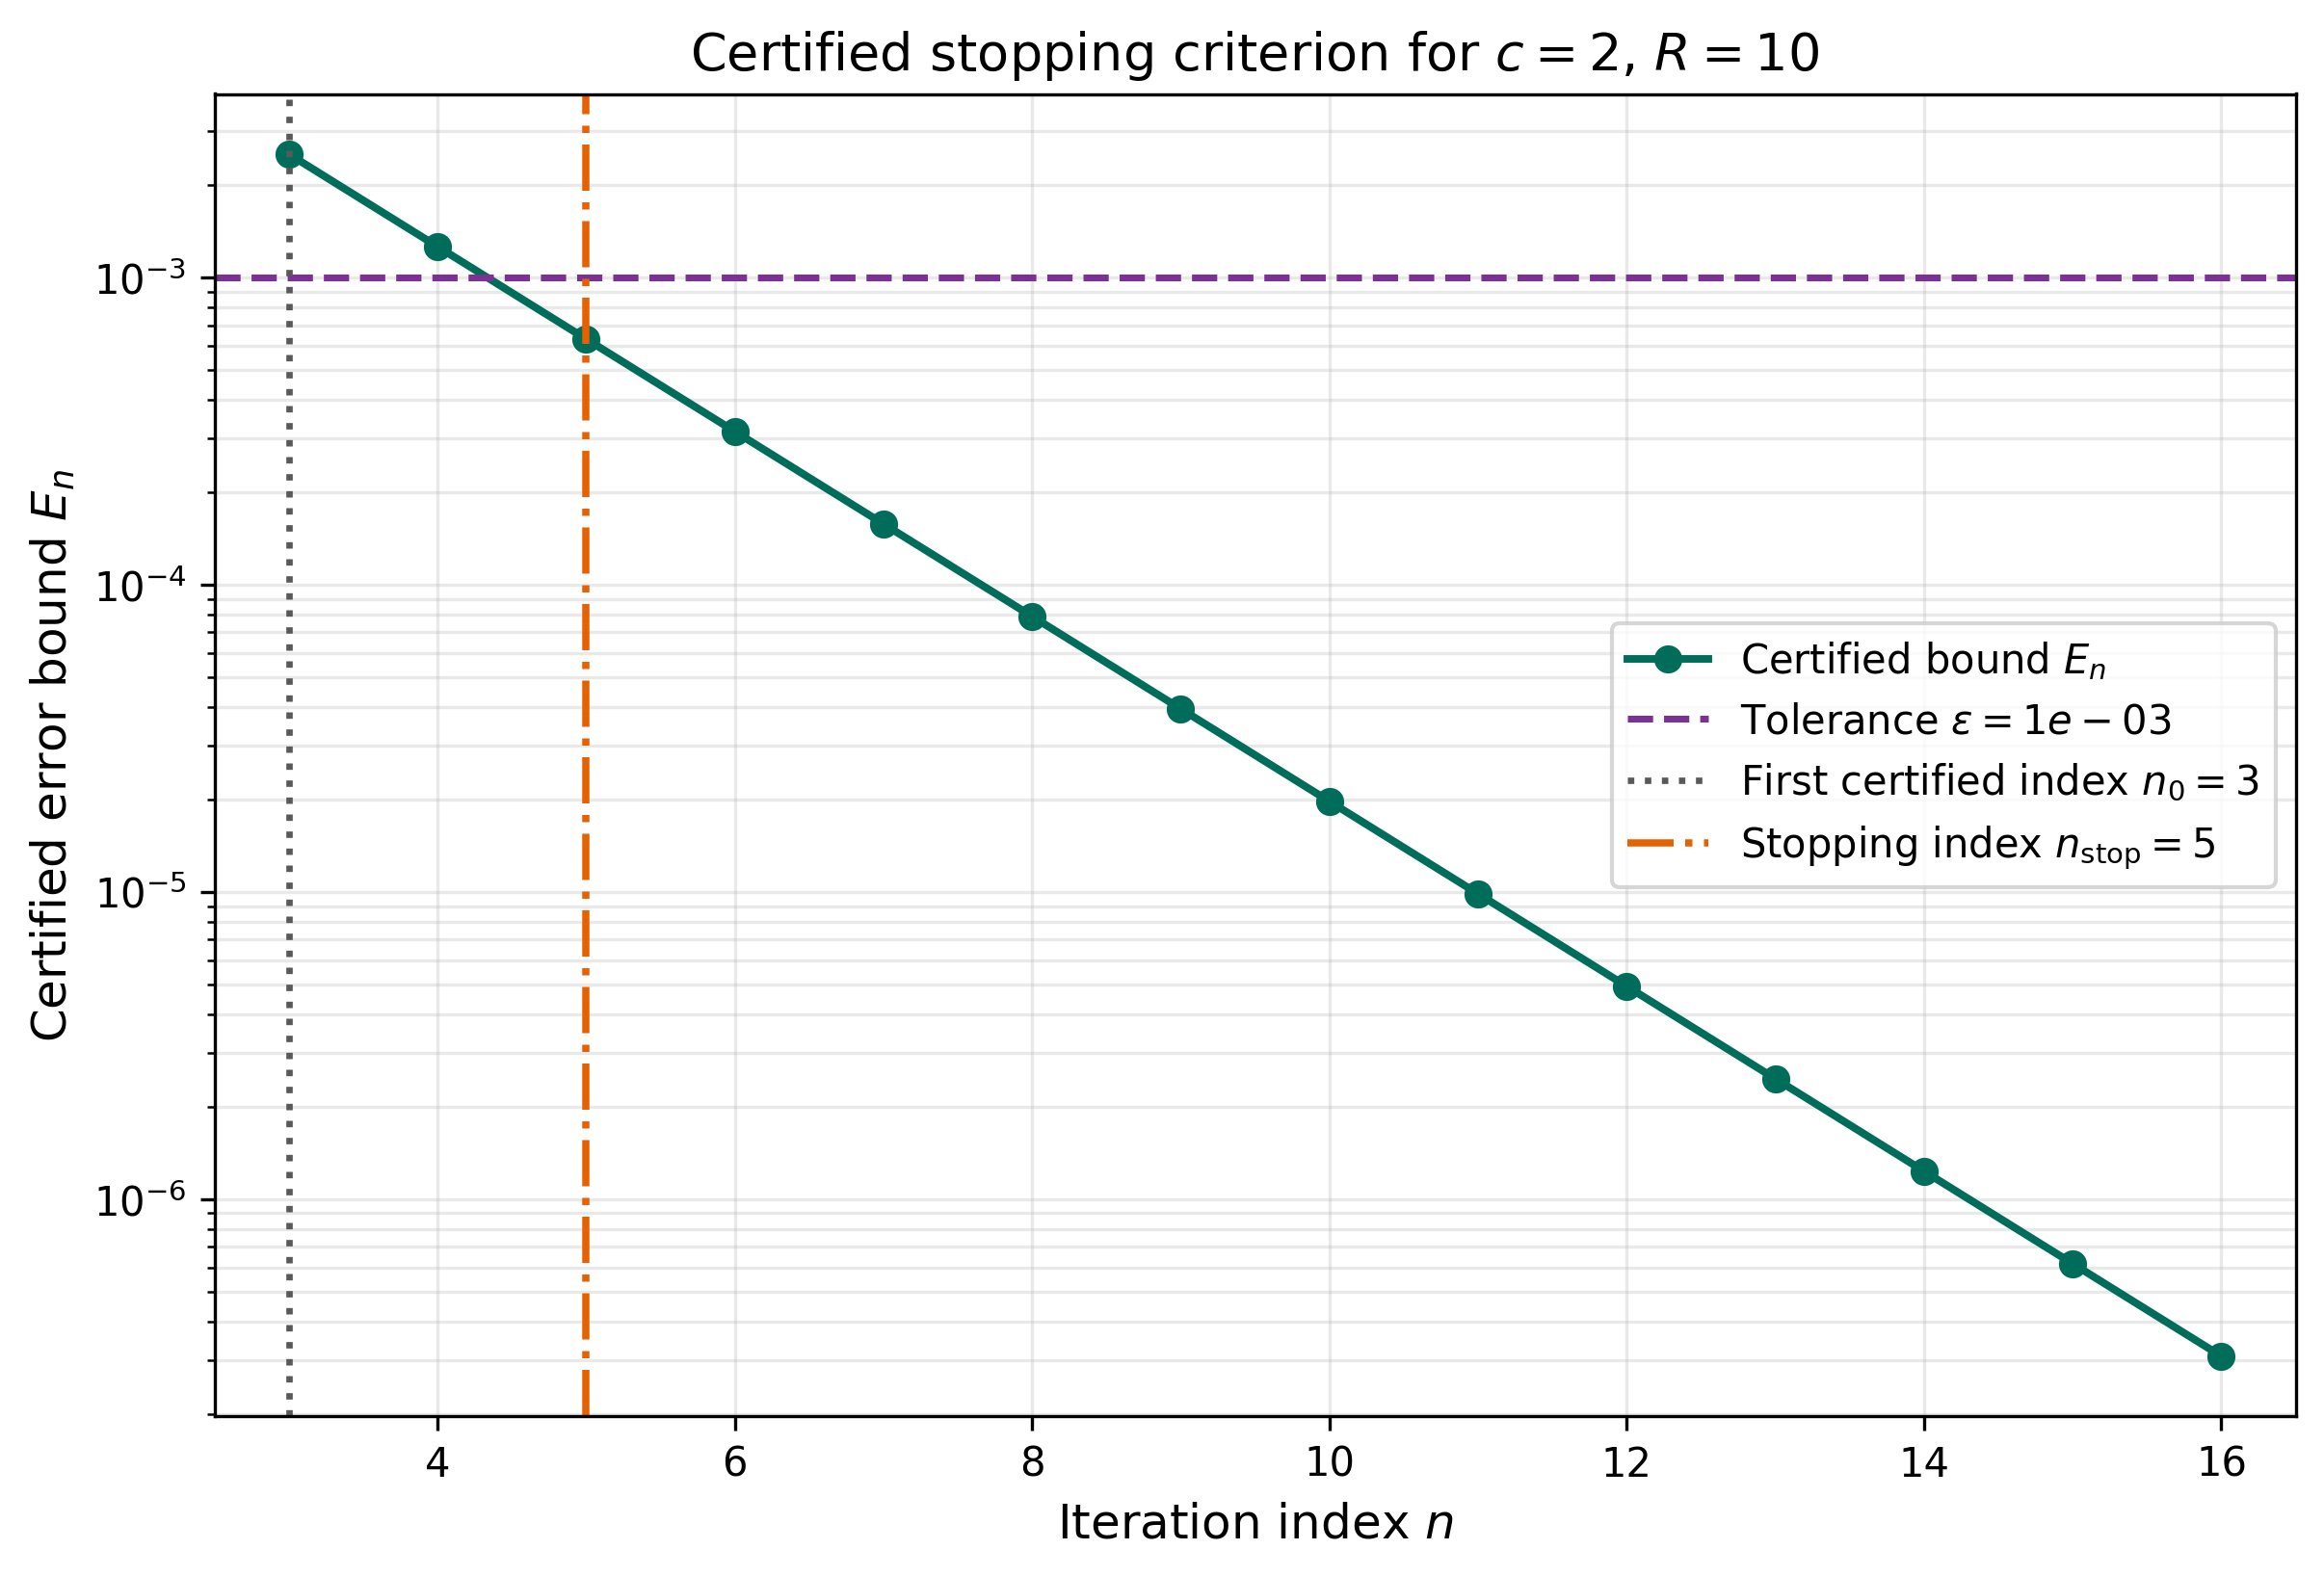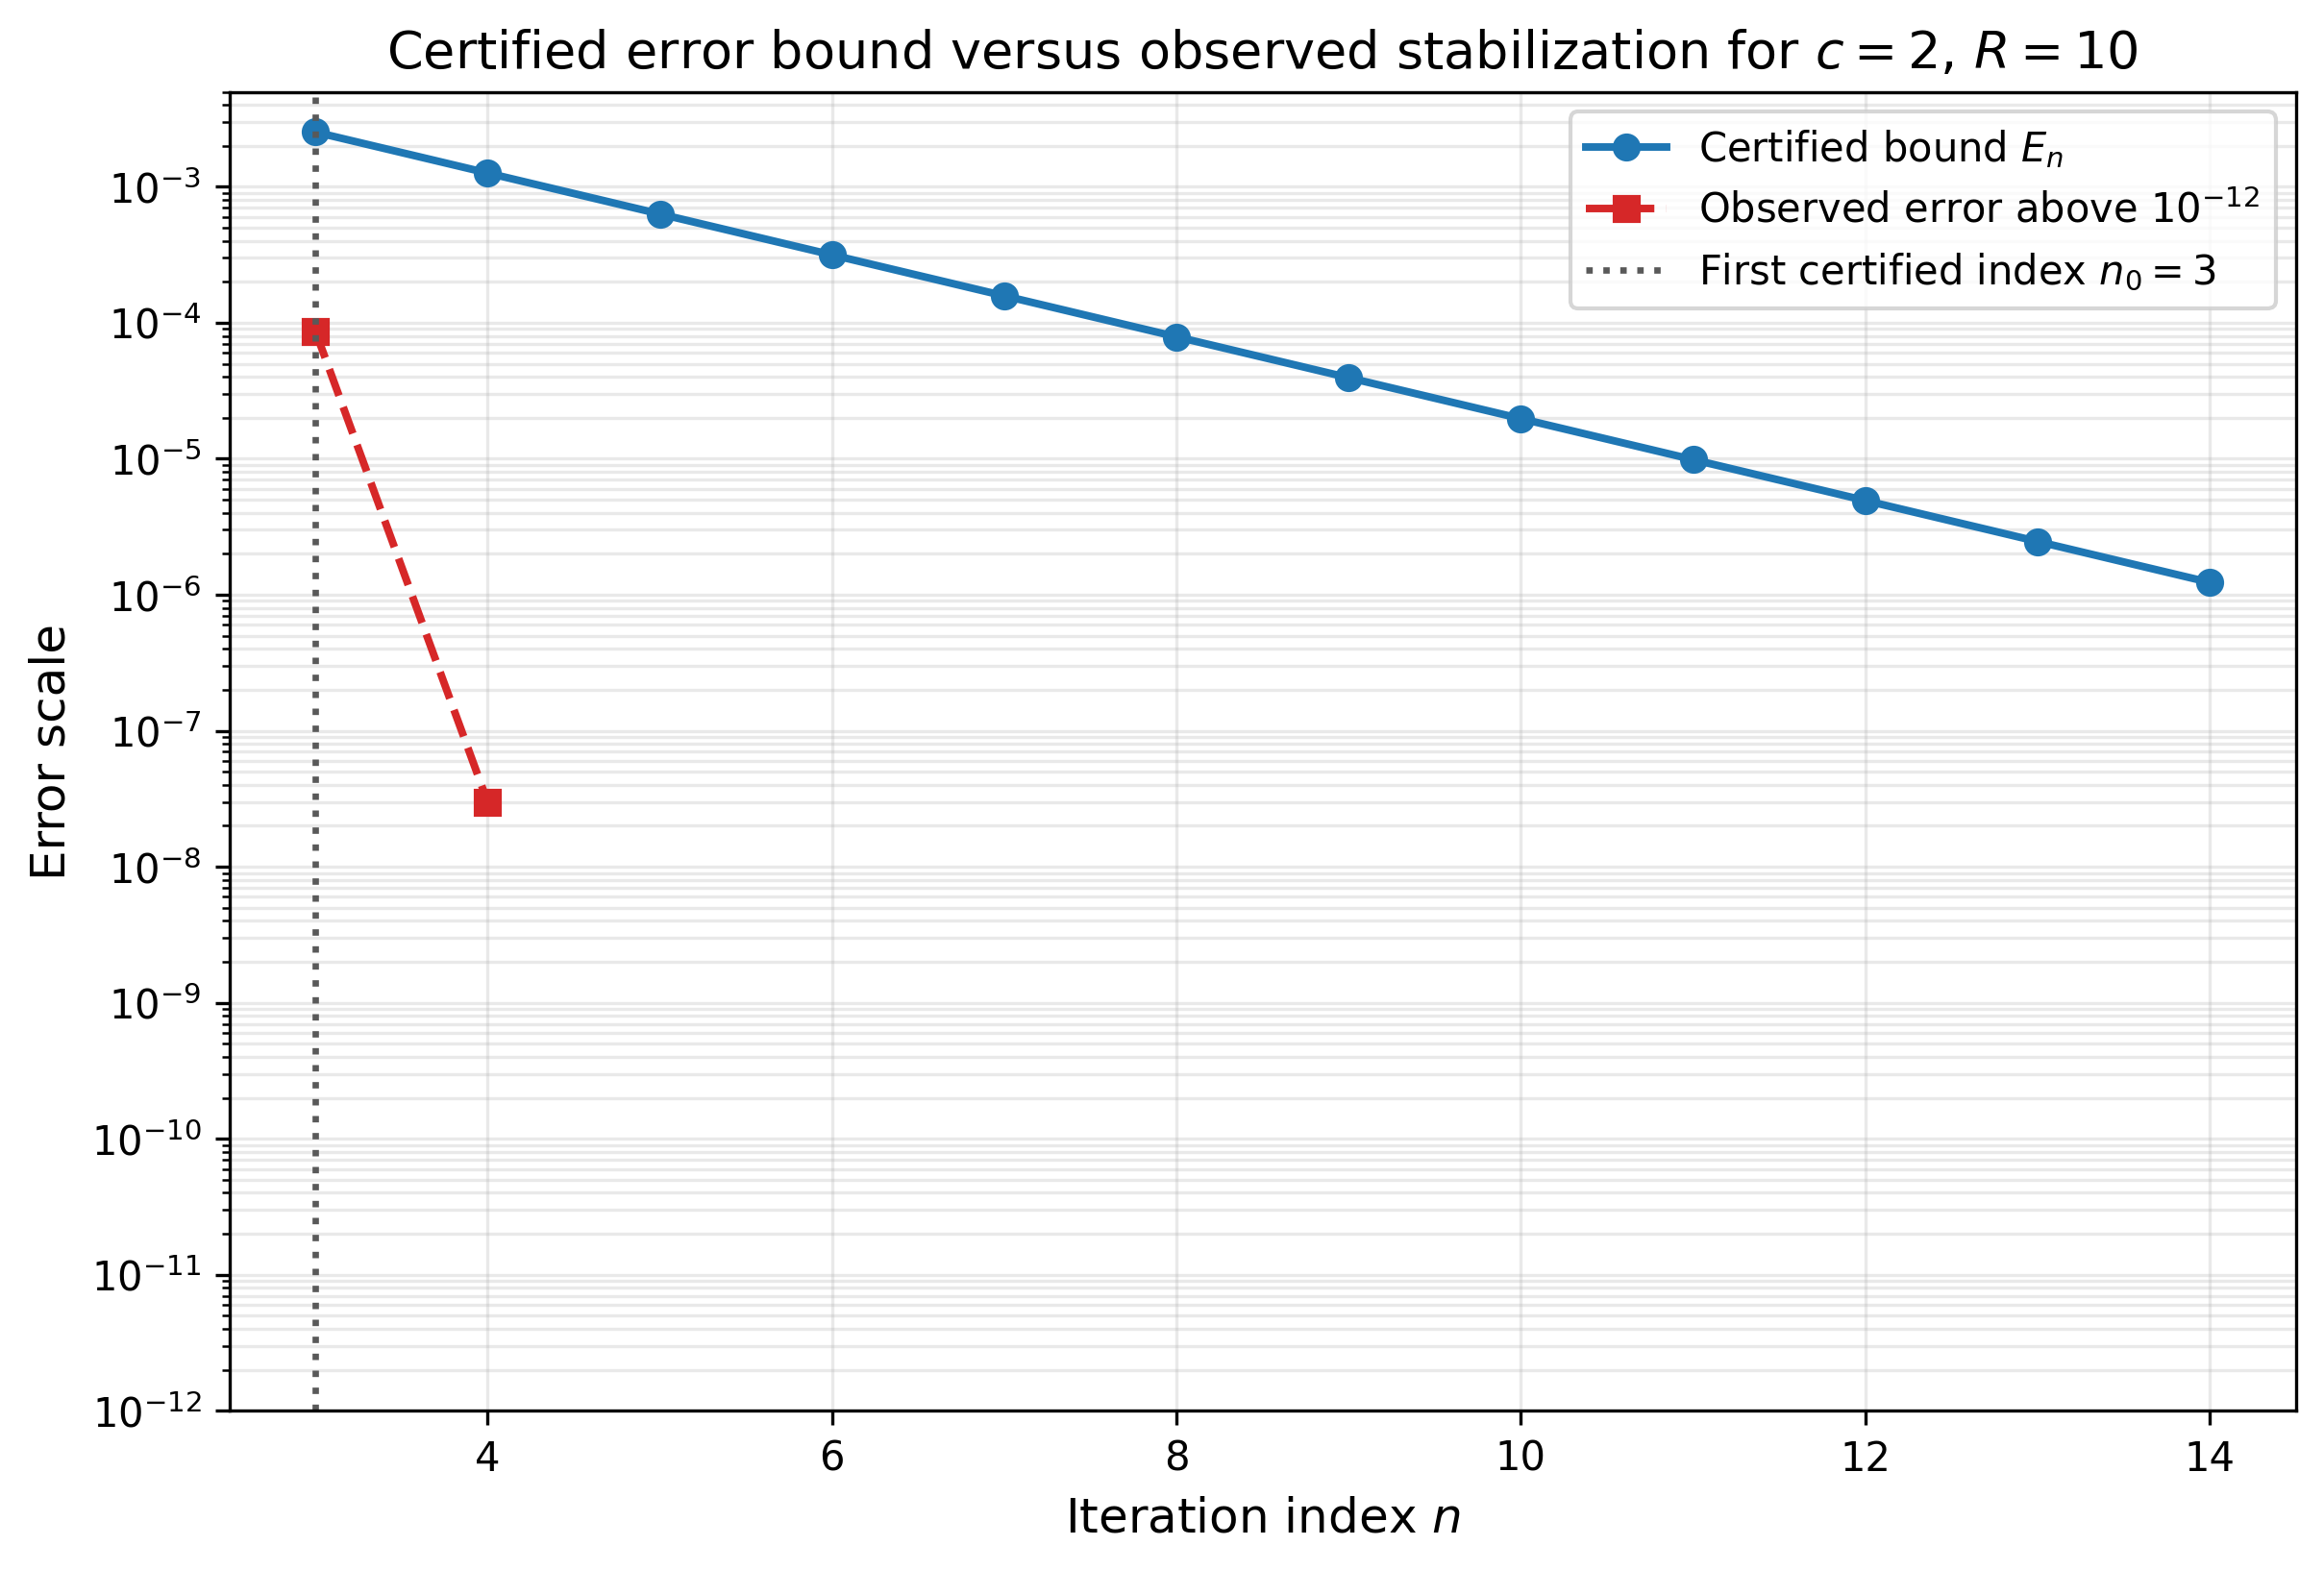

# Conclusion

In this paper, we investigated the regularized escape-rate function associated with the quadratic family

$$
f_c(z)=z^2+c,
\qquad
c\in\mathbb C,
$$

with critical orbit generated by

$$
z_0=0,
\qquad
z_{n+1}=z_n^2+c.
$$

The principal objective was to analyze the asymptotic behaviour of escaping critical orbits and to develop a mathematically rigorous framework for their numerical approximation.

The rapid growth of escaping orbits implies that the raw sequence

$$
|f_c^{\circ n}(0)|
$$

is not itself a convenient asymptotic observable. To overcome this difficulty, we considered the normalized quantities

$$
G_n(c)
=
\frac{\log^+|z_n|}{2^n},
$$

and the corresponding escape-rate function

$$
G(c)
=
\lim_{n\to\infty}G_n(c).
$$

This regularization transforms the double-exponential growth of escaping orbits into a finite quantity that captures the leading asymptotic behaviour of the dynamics.

From the theoretical perspective, we established the existence of the escape-rate limit in the escaping regime and verified its vanishing on bounded critical orbits. We further showed that the escape-rate function governs the asymptotic growth of the orbit through the relations

$$
\log|z_n|
=
2^nG(c)+o(2^n),
$$

and equivalently,

$$
|z_n|
=
\exp\!\bigl(2^nG(c)+o(2^n)\bigr).
$$

These formulas provide a precise quantitative description of escape and identify $G(c)$ as the leading asymptotic coefficient controlling orbit growth.

A central contribution of the paper is the development of a quantitative convergence theory for the finite approximants $G_n(c)$. By introducing an admissible escape radius

$$
R>\max\left\{2,\sqrt{2|c|}\right\},
$$

we derived the certified error estimate

$$
|G(c)-G_n(c)|
\le
\frac{1}{2^n}
\left[
-\log\left(
1-\frac{|c|}{R^2}
\right)
\right].
$$

This result establishes exponential convergence of order $O(2^{-n})$ and provides an explicit and computable upper bound for the approximation error. As a consequence, the computation of escape-rate values can be performed with mathematically certified accuracy rather than relying solely on empirical stabilization.

The quantitative error estimate further leads to a rigorous stopping criterion for prescribed tolerance. By inverting the convergence bound, we obtained an explicit theoretical stopping index that guarantees a desired accuracy level. This transforms the asymptotic theory into a practical numerical procedure and provides a direct connection between mathematical analysis and certified computation.

The numerical experiments presented throughout the paper support the theoretical results and illustrate the effectiveness of the regularized framework. The computed examples demonstrate that the escape-rate function is genuinely parameter dependent, distinguish bounded and escaping dynamics, and exhibit the predicted convergence behaviour of the finite approximants. The accompanying visualizations reveal the geometric structure of the escape-rate field, its equipotential contours, and its relationship with the Mandelbrot set.

From a broader perspective, the escape-rate function may be viewed as a canonical potential-theoretic object associated with the quadratic family. The regularization procedure converts unstable divergence into a structured and computable invariant that simultaneously reflects orbit growth, parameter-space geometry, and asymptotic dynamics. In this way, the escape-rate function serves as a natural bridge between complex dynamics, numerical analysis, and potential theory.

Several directions remain open for further investigation. These include the derivation of sharper finite-step error estimates, convergence analysis near the boundary $\partial\mathcal M,$  extensions to higher-degree polynomial families, and computational studies of escape-rate level sets and equipotential structures. Such problems suggest that the regularized escape-rate framework developed here may provide a useful foundation for future work on asymptotic escape phenomena in complex dynamical systems.

In summary, the paper establishes a rigorous asymptotic, quantitative, and computational theory for the regularized escape-rate function of the quadratic family. The resulting framework combines theoretical analysis, certified approximation, and numerical visualization into a unified approach for studying escape dynamics in complex quadratic iteration.